# DANCE: Distilled Attention-based Neural Contrastive Encoder
## CSE400C Capstone — Phase B Reproduction + Phase C Full Benchmark
### A Lightweight Distilled Framework for Subject-Independent EEG-Based Emotion Recognition

**Team:** Osama Bin Qashem · K. M Fahim A. Bari · Saif Khan · Rafid Rahman  
**Supervisor:** Dr. Ahmed Wasif Reza (DAWR)

---

### Notebook Structure
| Section | Content |
|---------|---------|
| **Part 0** | Configuration, imports, helpers |
| **Part 1** | Data loading & EDA (Phase B reproduced) |
| **Part 2** | DANCE Architecture library (Phase B reproduced) |
| **Part 3** | Teacher training — contrastive pretrain + finetune |
| **Part 4** | Phase B Reproduction Check (fixed split) |
| **Part 5** | LOSO-15 harness — true evaluation protocol |
| **Part 6** | Classical ML baselines M01–M10 |
| **Part 7** | Deep learning baselines M11–M20 (incl. NEW: DANN, Conformer) |
| **Part 8** | SSL & Semi-supervised M21–M24 |
| **Part 9** | Cross-dataset evaluation E03–E06 |
| **Part 10** | Ablation studies A01–A16 |
| **Part 11** | Visualisations — t-SNE by subject & emotion |
| **Part 12** | Statistical significance |
| **📊 FINAL** | Master report cell — run this to get all numbers |


## Part 0 · Configuration & Imports

In [1]:
# ── Path Configuration ───────────────────────────────────────────────────────
import os, sys

# Detect environment (Kaggle vs local)
if os.path.exists('/kaggle/input/seed-iv'):
    SEED_IV_PATH = '/kaggle/input/seed-iv'
    ROOT = '/kaggle/working'
elif os.path.exists('data/SEED_IV/ExtractedFeatures'):
    SEED_IV_PATH = 'data/SEED_IV'
    ROOT = '.'
elif os.path.exists('../data/SEED_IV/ExtractedFeatures'):
    SEED_IV_PATH = '../data/SEED_IV'
    ROOT = '..'
else:
    raise FileNotFoundError(
        "SEED-IV not found. Expected at data/SEED_IV/ExtractedFeatures/ "
        "or /kaggle/input/seed-iv/eeg_feature_smooth/"
    )

FACED_PATH  = os.path.join(ROOT, 'data/FACED/EEG_Features/DE')
DEAP_PATH   = os.path.join(ROOT, 'data/DEAP/data_preprocessed_python')
FEAT_DIR    = os.path.join(ROOT, 'features');  os.makedirs(FEAT_DIR, exist_ok=True)
CKPT_DIR    = os.path.join(ROOT, 'checkpoints'); os.makedirs(CKPT_DIR, exist_ok=True)
RESULTS_DIR = os.path.join(ROOT, 'results');   os.makedirs(RESULTS_DIR, exist_ok=True)
for sub in ['phaseB_reproduction','loso','classical_ml','deep_models',
            'ssl_semisl','cross_dataset','ablations','statistical']:
    os.makedirs(os.path.join(RESULTS_DIR, sub), exist_ok=True)
FIG_DIR = os.path.join(ROOT, 'figures'); os.makedirs(FIG_DIR, exist_ok=True)

print(f"SEED-IV path : {SEED_IV_PATH}")
print(f"Root         : {ROOT}")


SEED-IV path : data/SEED_IV
Root         : .


In [2]:
# ── Standard Imports ─────────────────────────────────────────────────────────
import numpy as np
import scipy.io
import scipy.signal
import os, glob, warnings, copy, math, random
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              precision_recall_fscore_support)
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — M09 will be skipped. pip install xgboost")

try:
    from scipy.stats import wilcoxon, friedmanchisquare
    HAS_STATS = True
except ImportError:
    HAS_STATS = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")


XGBoost not installed — M09 will be skipped. pip install xgboost
Device: cuda


In [3]:
# ── Global Seed ──────────────────────────────────────────────────────────────
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(42)

# ── Constants ─────────────────────────────────────────────────────────────────
NUM_SUBJECTS  = 15
NUM_SESSIONS  = 3
NUM_CHANNELS  = 62
NUM_BANDS     = 5
NUM_CLASSES   = 4
EMOTION_NAMES = ['Neutral', 'Sad', 'Fear', 'Happy']
ALL_SUBJECTS  = list(range(1, 16))

# SEED-IV channel ordering (standard 10-20, from Phase B notebook)
SEED_CHANNELS = [
    'FP1','FPZ','FP2','AF3','AF4','F7','F5','F3','F1','FZ',
    'F2','F4','F6','F8','FT7','FC5','FC3','FC1','FCZ','FC2',
    'FC4','FC6','FT8','T7','C5','C3','C1','CZ','C2','C4',
    'C6','T8','TP7','CP5','CP3','CP1','CPZ','CP2','CP4','CP6',
    'TP8','P7','P5','P3','P1','PZ','P2','P4','P6','P8',
    'PO7','PO5','PO3','POZ','PO4','PO6','PO8','CB1','O1','OZ',
    'O2','CB2'
]

# 6-channel student subset (CORRECTED — indices verified from Phase B code)
STUDENT_CHANNEL_NAMES   = ['FP1', 'FP2', 'F7', 'F8', 'T7', 'T8']
STUDENT_CHANNEL_INDICES = [SEED_CHANNELS.index(ch) for ch in STUDENT_CHANNEL_NAMES]
print(f"Student channel indices: {STUDENT_CHANNEL_INDICES}")
# Expected: [0, 2, 5, 13, 23, 31]

# Session emotion labels (hardcoded — DO NOT CHANGE)
SESSION_LABELS = {
    1: [1,2,3,0,2,0,0,1,0,1,2,1,1,1,2,3,2,2,3,3,0,3,0,3],
    2: [2,1,3,0,0,2,0,2,3,3,2,3,2,0,1,1,2,1,0,3,0,1,3,1],
    3: [1,2,2,1,3,3,3,1,1,2,1,0,2,3,3,0,2,3,0,0,2,0,1,0]
}  # 0=neutral 1=sad 2=fear 3=happy


Student channel indices: [0, 2, 5, 13, 23, 31]


## Part 1 · Data Loading & EDA

In [4]:
# ── SEED-IV Loader (exact Phase B logic) ──────────────────────────────────────
def load_seed_iv_lds(path):
    # Support both Kaggle and local layouts
    feature_root = None
    for candidate in [
        os.path.join(path, 'ExtractedFeatures'),
        os.path.join(path, 'eeg_feature_smooth'),
        os.path.join(path, 'eeg_feature_smooth', 'eeg_feature_smooth'),
        path
    ]:
        if os.path.exists(os.path.join(candidate, '1')):
            feature_root = candidate
            break
    if feature_root is None:
        raise FileNotFoundError(f"Cannot find SEED-IV session folders under {path}")
    print(f"Loading from: {feature_root}")

    X_t, X_s, y_arr, subj_arr, sess_arr = [], [], [], [], []
    for session_id in [1, 2, 3]:
        session_path = os.path.join(feature_root, str(session_id))
        if not os.path.exists(session_path):
            print(f"  Session {session_id} path missing: {session_path}"); continue
        files = sorted([f for f in os.listdir(session_path) if f.endswith('.mat')])
        for fname in tqdm(files, desc=f"Session {session_id}"):
            try:
                subject_id = int(fname.split('_')[0])
                mat = scipy.io.loadmat(os.path.join(session_path, fname))
            except Exception as e:
                print(f"  Skipping {fname}: {e}"); continue
            for i, label in enumerate(SESSION_LABELS[session_id]):
                key = f'de_LDS{i+1}'
                if key not in mat: continue
                # mat[key]: (62, T, 5) → (T, 62, 5)
                trial = np.transpose(mat[key], (1, 0, 2)).astype(np.float32)
                n_win = trial.shape[0]
                X_t.append(trial)
                X_s.append(trial[:, STUDENT_CHANNEL_INDICES, :])
                y_arr.append(np.full(n_win, label, dtype=np.int64))
                subj_arr.append(np.full(n_win, subject_id, dtype=np.int64))
                sess_arr.append(np.full(n_win, session_id, dtype=np.int64))

    return (np.concatenate(X_t), np.concatenate(X_s),
            np.concatenate(y_arr), np.concatenate(subj_arr), np.concatenate(sess_arr))


def apply_subject_zscore(data, subject_ids):
    print("Applying subject-specific z-score normalisation...")
    out = np.zeros_like(data, dtype=np.float32)
    for sub in np.unique(subject_ids):
        mask = subject_ids == sub
        mu   = data[mask].mean(axis=0, keepdims=True)
        sig  = data[mask].std(axis=0, keepdims=True)
        sig  = np.where(sig < 1e-8, 1.0, sig)
        out[mask] = (data[mask] - mu) / sig
    return out


# ── Load & normalise ──────────────────────────────────────────────────────────
X_t_raw, X_s_raw, LABELS, SUBJ, SESS = load_seed_iv_lds(SEED_IV_PATH)
X_62 = apply_subject_zscore(X_t_raw, SUBJ)   # (N, 62, 5)
X_6  = apply_subject_zscore(X_s_raw, SUBJ)   # (N,  6, 5)
X_62_flat = X_62.reshape(len(X_62), -1)       # (N, 310)  for classical ML
X_6_flat  = X_6.reshape(len(X_6),  -1)        # (N,  30)  for classical ML

# Save features
np.save(f'{FEAT_DIR}/seed_iv_X_62ch.npy', X_62_flat)
np.save(f'{FEAT_DIR}/seed_iv_X_6ch.npy',  X_6_flat)
np.save(f'{FEAT_DIR}/seed_iv_y_4cls.npy', LABELS)
np.save(f'{FEAT_DIR}/seed_iv_subjects.npy', SUBJ)
np.save(f'{FEAT_DIR}/seed_iv_session.npy', SESS)

print(f"\nTotal windows : {len(LABELS):,}")
print(f"Teacher shape  : {X_62.shape}")
print(f"Student shape  : {X_6.shape}")
print(f"Label dist     : {dict(zip(*np.unique(LABELS, return_counts=True)))}")


Loading from: data/SEED_IV\ExtractedFeatures


Session 1:   0%|          | 0/15 [00:00<?, ?it/s]

Session 2:   0%|          | 0/15 [00:00<?, ?it/s]

Session 3:   0%|          | 0/15 [00:00<?, ?it/s]

Applying subject-specific z-score normalisation...
Applying subject-specific z-score normalisation...

Total windows : 37,575
Teacher shape  : (37575, 62, 5)
Student shape  : (37575, 6, 5)
Label dist     : {np.int64(0): np.int64(10170), np.int64(1): np.int64(10245), np.int64(2): np.int64(9225), np.int64(3): np.int64(7935)}


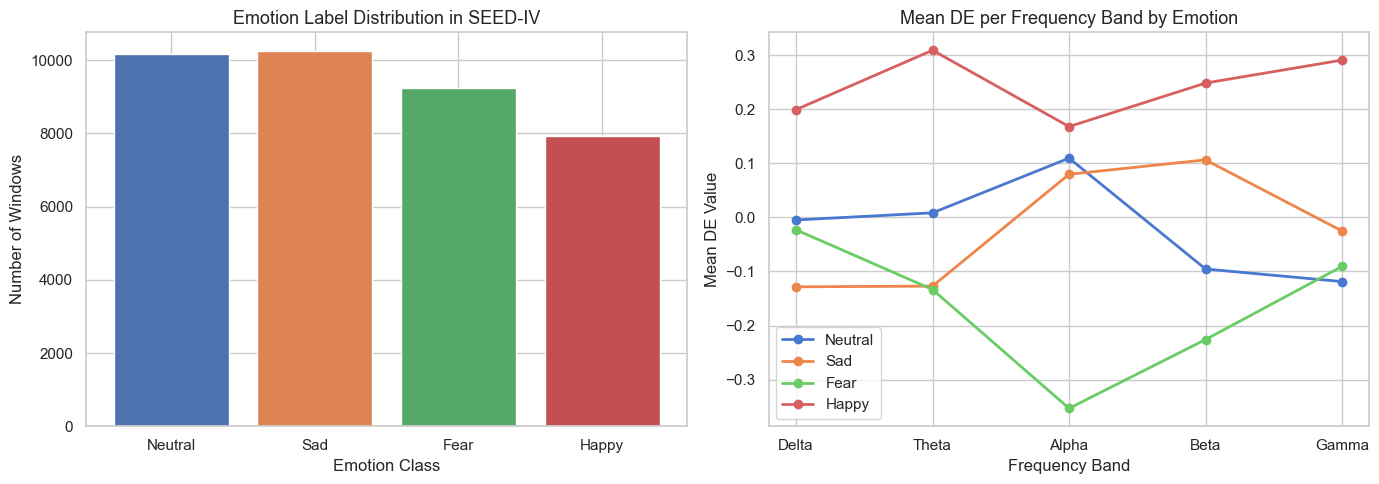

Figure saved: eda_overview.png


In [5]:
# ── EDA Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution
counts = np.bincount(LABELS)
axes[0].bar(EMOTION_NAMES, counts, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('Emotion Label Distribution in SEED-IV', fontsize=13)
axes[0].set_xlabel('Emotion Class'); axes[0].set_ylabel('Number of Windows')

# Mean DE per band per emotion
band_names = ['Delta','Theta','Alpha','Beta','Gamma']
for e_idx, name in enumerate(EMOTION_NAMES):
    mask = LABELS == e_idx
    mean_de = X_62[mask].mean(axis=(0, 2))   # mean over samples and channels → (62,)
    # mean over channels to get (5,) per band
    mean_de_band = X_62[mask].mean(axis=(0, 1))  # (5,)
    axes[1].plot(band_names, mean_de_band, marker='o', label=name, linewidth=2)
axes[1].set_title('Mean DE per Frequency Band by Emotion', fontsize=13)
axes[1].set_xlabel('Frequency Band'); axes[1].set_ylabel('Mean DE Value')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: eda_overview.png")


## Part 2 · DANCE Architecture Library

In [6]:
# ── Augmentor ─────────────────────────────────────────────────────────────────
class EEGAugmentor(nn.Module):
    def __init__(self, mixup_alpha=0.4, mask_ratio=0.3, mask_value=0.0, noise_std=0.1):
        super().__init__()
        self.mixup_alpha = mixup_alpha
        self.mask_ratio  = mask_ratio
        self.mask_value  = mask_value
        self.noise_std   = noise_std

    def mixup(self, x, y, subject_ids):
        batch_size = x.size(0)
        lam = np.random.beta(self.mixup_alpha, self.mixup_alpha) if self.mixup_alpha > 0 else 1.0
        indices = []
        for i in range(batch_size):
            diff_mask = subject_ids != subject_ids[i]
            if diff_mask.sum() > 0:
                valid = torch.where(diff_mask)[0]
                idx = valid[torch.randint(len(valid),(1,))]
            else:
                idx = torch.randint(batch_size,(1,))
            indices.append(idx)
        indices = torch.cat(indices)
        x_mixed = lam * x + (1-lam) * x[indices]
        return x_mixed, y, y[indices], lam

    def channel_mask(self, x):
        B, C, D = x.shape
        n_mask = int(C * self.mask_ratio)
        mask = torch.ones(B, C, dtype=torch.bool, device=x.device)
        for i in range(B):
            mask[i, torch.randperm(C)[:n_mask]] = False
        xm = x.clone(); xm[~mask] = self.mask_value
        return xm

    def add_noise(self, x):
        return x + torch.randn_like(x) * self.noise_std

    def forward(self, x, y=None, subject_ids=None, return_two_views=True):
        if return_two_views:
            v1 = self.add_noise(self.channel_mask(x))
            v2 = self.add_noise(self.channel_mask(x))
            if y is not None and subject_ids is not None and np.random.random() > 0.5:
                v2, _, _, _ = self.mixup(v2, y, subject_ids)
            return v1, v2
        return self.add_noise(self.channel_mask(x))


# ── Information-Separated Attention (diagonal masking TRAINING-ONLY) ──────────
class InformationSeparatedAttention(nn.Module):
    def __init__(self, d_model=32, n_heads=4, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale   = math.sqrt(self.d_k)

    def forward(self, query, key, value):
        B, S, _ = query.shape
        Q = self.W_q(query).view(B,S,self.n_heads,self.d_k).transpose(1,2)
        K = key.view(B,S,self.n_heads,self.d_k).transpose(1,2)
        V = value.view(B,S,self.n_heads,self.d_k).transpose(1,2)
        scores = torch.matmul(Q, K.transpose(-2,-1)) / self.scale
        # Diagonal masking: TRAINING ONLY (gap documented in Plan v3 Section 0 Gap 5)
        if self.training:
            diag_mask = 1 - torch.eye(S, device=query.device)
            scores = scores.masked_fill(diag_mask.unsqueeze(0).unsqueeze(0)==0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out  = torch.matmul(attn, V).transpose(1,2).contiguous().view(B,S,self.d_model)
        return self.W_o(out)


class DiagonalTransformerBlock(nn.Module):
    def __init__(self, d_model=32, n_heads=4, d_ff=128, dropout=0.1):
        super().__init__()
        self.attention = InformationSeparatedAttention(d_model, n_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout)
        )

    def forward(self, x, k_fixed, v_fixed):
        x = x + self.attention(self.norm1(x), k_fixed, v_fixed)
        x = x + self.ffn(self.norm2(x))
        return x


class DANCEEncoder(nn.Module):
    def __init__(self, n_channels=62, n_bands=5, d_model=32, n_heads=4,
                 n_layers=4, d_ff=128, dropout=0.2):
        super().__init__()
        self.input_projection = nn.Linear(n_bands, d_model)
        self.register_buffer('pos_embedding', self._sinusoidal(n_channels, d_model))
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.layers = nn.ModuleList([
            DiagonalTransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    @staticmethod
    def _sinusoidal(n_pos, d_model):
        pe = torch.zeros(n_pos, d_model)
        pos = torch.arange(0, n_pos, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0,d_model,2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe.unsqueeze(0)

    def forward(self, x):
        x = self.input_projection(x) + self.pos_embedding
        x = self.dropout(x)
        k_fixed = self.W_k(x)
        v_fixed = self.W_v(x)
        q = x
        for layer in self.layers:
            q = layer(q, k_fixed, v_fixed)
        return self.norm(q).mean(dim=1)   # global average pool → (B, d_model)


class DANCEModel(nn.Module):
    def __init__(self, n_channels=62, n_bands=5, d_model=32, n_heads=4,
                 n_layers=4, d_ff=128, d_proj=128, n_classes=4, dropout=0.2):
        super().__init__()
        self.augmentor = EEGAugmentor()
        self.encoder   = DANCEEncoder(n_channels, n_bands, d_model,
                                       n_heads, n_layers, d_ff, dropout)
        self.projector = nn.Sequential(
            nn.Linear(d_model,128), nn.BatchNorm1d(128), nn.ELU(),
            nn.Linear(128, 256),   nn.BatchNorm1d(256), nn.ELU(),
            nn.Linear(256, d_proj)
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Dropout(dropout),
            nn.Linear(d_model, d_model), nn.ELU(),
            nn.Linear(d_model, n_classes)
        )

    def forward_contrastive(self, x, labels=None, subject_ids=None):
        v1, v2 = self.augmentor(x, labels, subject_ids)
        return (self.projector(self.encoder(v1)),
                self.projector(self.encoder(v2)))

    def forward(self, x):
        return self.classifier(self.encoder(x))

    def get_features(self, x):
        return self.encoder(x)

print("DANCE architecture defined ✓")


DANCE architecture defined ✓


In [7]:
# ── Dataset / DataLoaders ─────────────────────────────────────────────────────
class SEEDDataset(Dataset):
    def __init__(self, features, labels, subject_ids, flatten=False):
        self.features    = torch.tensor(features, dtype=torch.float32)
        self.labels      = torch.tensor(labels, dtype=torch.long)
        self.subject_ids = torch.tensor(subject_ids, dtype=torch.long)
        self.flatten     = flatten
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        x = self.features[i]
        if self.flatten:
            x = x.view(-1)
        return {'features': x, 'label': self.labels[i],
                'subject_id': self.subject_ids[i]}


class PairedDataset(Dataset):
    '''Teacher (62-ch) + Student (6-ch) pairs for distillation.'''
    def __init__(self, X_t, X_s, labels, subject_ids):
        self.t   = torch.tensor(X_t, dtype=torch.float32)
        self.s   = torch.tensor(X_s, dtype=torch.float32)
        self.l   = torch.tensor(labels, dtype=torch.long)
        self.sub = torch.tensor(subject_ids, dtype=torch.long)
    def __len__(self):  return len(self.l)
    def __getitem__(self, i):
        return {'t': self.t[i], 's': self.s[i], 'l': self.l[i], 'sub': self.sub[i]}


def make_loaders(X_62, X_6, labels, subjects, train_mask, val_mask, test_mask,
                 batch_size=256):
    '''Build train/val/test DataLoaders for teacher (62-ch) training.'''
    def weighted_sampler(y):
        counts = np.bincount(y)
        weights = 1.0 / counts[y]
        return WeightedRandomSampler(torch.tensor(weights, dtype=torch.float),
                                     num_samples=len(weights), replacement=True)

    train_ds = SEEDDataset(X_62[train_mask], labels[train_mask], subjects[train_mask])
    val_ds   = SEEDDataset(X_62[val_mask],   labels[val_mask],   subjects[val_mask])
    test_ds  = SEEDDataset(X_62[test_mask],  labels[test_mask],  subjects[test_mask])

    return {
        'train': DataLoader(train_ds, batch_size=batch_size, drop_last=True,
                            sampler=weighted_sampler(labels[train_mask])),
        'val':   DataLoader(val_ds,   batch_size=batch_size, shuffle=False),
        'test':  DataLoader(test_ds,  batch_size=batch_size, shuffle=False),
    }, {'train': train_ds, 'val': val_ds, 'test': test_ds}

print("Dataset utilities defined ✓")


Dataset utilities defined ✓


In [8]:
# ── Cross-Subject Contrastive Loss (Phase B exact) ────────────────────────────
class CrossSubjectContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.5, subject_weight=0.5):
        super().__init__()
        self.temperature    = temperature
        self.subject_weight = subject_weight

    def forward(self, z1, z2, labels, subject_ids):
        B = z1.size(0); device = z1.device
        z1 = F.normalize(z1, dim=1); z2 = F.normalize(z2, dim=1)
        z  = torch.cat([z1, z2], dim=0)
        la = torch.cat([labels, labels], dim=0)
        sa = torch.cat([subject_ids, subject_ids], dim=0)
        sim = torch.matmul(z, z.T) / self.temperature
        labels_eq  = la.unsqueeze(0) == la.unsqueeze(1)
        subjects_eq= sa.unsqueeze(0) == sa.unsqueeze(1)
        self_mask  = torch.eye(2*B, dtype=torch.bool, device=device)
        pos_mask   = labels_eq & ~self_mask
        weight     = 1.0 + (~subjects_eq).float() * self.subject_weight
        pw         = pos_mask.float() * weight
        pw         = pw / (pw.sum(dim=1, keepdim=True) + 1e-8)
        exp_sim    = torch.exp(sim) * (~self_mask).float()
        log_prob   = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
        loss       = -(pw * log_prob).sum(dim=1)
        valid      = pos_mask.sum(dim=1) > 0
        return loss[valid].mean() if valid.any() else torch.tensor(0.0, device=device, requires_grad=True)


# ── Stage 1: Contrastive pretraining ─────────────────────────────────────────
def train_contrastive_stage(model, train_loader, epochs=30, lr=1e-3,
                             weight_decay=1e-4, device=DEVICE):
    model = model.to(device)
    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion  = CrossSubjectContrastiveLoss(temperature=0.5)
    history    = {'loss': []}
    for epoch in range(epochs):
        model.train(); total_loss = 0; nb = 0
        for batch in train_loader:
            x = batch['features'].to(device)
            if x.dim() == 2: x = x.view(x.size(0), -1, 5)
            la = batch['label'].to(device); su = batch['subject_id'].to(device)
            optimizer.zero_grad()
            z1, z2 = model.forward_contrastive(x, la, su)
            loss = criterion(z1, z2, la, su)
            loss.backward(); optimizer.step()
            total_loss += loss.item(); nb += 1
        history['loss'].append(total_loss / max(nb,1)); scheduler.step()
        if (epoch+1) % 10 == 0:
            print(f"  Pretrain epoch {epoch+1:3d}/{epochs}  loss={history['loss'][-1]:.4f}")
    return model, history


# ── Stage 2: Supervised fine-tuning ──────────────────────────────────────────
def train_supervised_stage(model, train_loader, val_loader, epochs=40, lr=3e-4,
                            device=DEVICE):
    model = model.to(device)
    for p in model.projector.parameters(): p.requires_grad = False
    optimizer = optim.AdamW([
        {'params': model.encoder.parameters(),    'lr': lr * 0.1},
        {'params': model.classifier.parameters(), 'lr': lr}
    ], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    history   = {'train_loss': [], 'val_acc': []}
    best_acc  = 0.0; best_state = None
    for epoch in range(epochs):
        model.train(); tl = 0; nb = 0
        for batch in train_loader:
            x = batch['features'].to(device)
            if x.dim() == 2: x = x.view(x.size(0), -1, 5)
            y = batch['label'].to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward(); optimizer.step()
            tl += loss.item(); nb += 1
        history['train_loss'].append(tl / max(nb,1))
        model.eval(); cor = tot = 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch['features'].to(device)
                if x.dim() == 2: x = x.view(x.size(0), -1, 5)
                cor += (model(x).argmax(1) == batch['label'].to(device)).sum().item()
                tot += batch['label'].size(0)
        va = cor / max(tot, 1); history['val_acc'].append(va); scheduler.step()
        if va > best_acc: best_acc = va; best_state = copy.deepcopy(model.state_dict())
        if (epoch+1) % 10 == 0:
            print(f"  Finetune epoch {epoch+1:3d}/{epochs}  loss={history['train_loss'][-1]:.4f}  val_acc={va:.2%}")
    if best_state: model.load_state_dict(best_state)
    for p in model.projector.parameters(): p.requires_grad = True
    return model, history


# ── Calibration (Protocol B) ─────────────────────────────────────────────────
def calibrate_subject(model, x_cal, y_cal, num_steps=50, lr=1e-3, device=DEVICE):
    adapted = copy.deepcopy(model).to(device)
    adapted.train()
    opt = optim.Adam(adapted.classifier.parameters(), lr=lr)
    ce  = nn.CrossEntropyLoss()
    for _ in range(num_steps):
        opt.zero_grad()
        xc = x_cal if isinstance(x_cal, torch.Tensor) else torch.tensor(x_cal, dtype=torch.float32)
        xc = xc.to(device)
        if xc.dim() == 2: xc = xc.view(xc.size(0), -1, 5)
        yc = y_cal if isinstance(y_cal, torch.Tensor) else torch.tensor(y_cal, dtype=torch.long)
        yc = yc.to(device)
        loss = ce(adapted(xc), yc)
        loss.backward(); opt.step()
    adapted.eval()
    return adapted


# ── Metrics helper ────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred):
    return {
        'acc':       accuracy_score(y_true, y_pred),
        'macro_f1':  f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_prec':precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_rec': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

print("Loss functions & training engines defined ✓")


Loss functions & training engines defined ✓


## Part 3 · Teacher Training (Phase B Reproduced)

In [9]:
# ── Phase B fixed split ───────────────────────────────────────────────────────
TRAIN_SUBJ_PB = list(range(1, 11))   # subjects 1-10
VAL_SUBJ_PB   = [11, 12]
TEST_SUBJ_PB  = [13, 14, 15]

pb_train_mask = np.isin(SUBJ, TRAIN_SUBJ_PB)
pb_val_mask   = np.isin(SUBJ, VAL_SUBJ_PB)
pb_test_mask  = np.isin(SUBJ, TEST_SUBJ_PB)

pb_loaders, pb_splits = make_loaders(
    X_62, X_6, LABELS, SUBJ,
    pb_train_mask, pb_val_mask, pb_test_mask,
    batch_size=256
)

print(f"Phase B split:")
print(f"  Train : {pb_train_mask.sum():>6,}  (subjects {TRAIN_SUBJ_PB})")
print(f"  Val   : {pb_val_mask.sum():>6,}  (subjects {VAL_SUBJ_PB})")
print(f"  Test  : {pb_test_mask.sum():>6,}  (subjects {TEST_SUBJ_PB})")


Phase B split:
  Train : 25,050  (subjects [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
  Val   :  5,010  (subjects [11, 12])
  Test  :  7,515  (subjects [13, 14, 15])


Stage 1: Contrastive pre-training (30 epochs)...
  Pretrain epoch  10/30  loss=5.8423
  Pretrain epoch  20/30  loss=5.6513
  Pretrain epoch  30/30  loss=5.5320


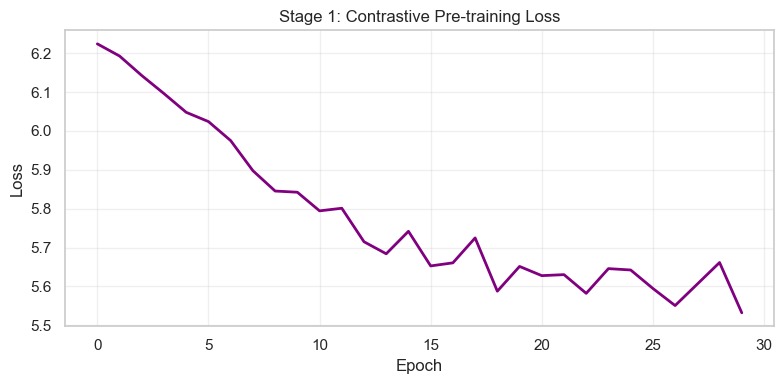

In [10]:
# ── Train Teacher (Stage 1: contrastive pretrain) ────────────────────────────
set_global_seed(42)
teacher_pb = DANCEModel(
    n_channels=62, n_bands=5, d_model=32, n_heads=4, n_layers=4,
    d_ff=128, d_proj=128, n_classes=4, dropout=0.2
).to(DEVICE)

print("Stage 1: Contrastive pre-training (30 epochs)...")
teacher_pb, pretrain_hist = train_contrastive_stage(
    teacher_pb, pb_loaders['train'], epochs=30, lr=1e-3, device=DEVICE
)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(pretrain_hist['loss'], color='purple', linewidth=2)
ax.set_title('Stage 1: Contrastive Pre-training Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pretrain_loss.png', dpi=150, bbox_inches='tight')
plt.show()

torch.save(teacher_pb.state_dict(), f'{CKPT_DIR}/teacher_pretrained.pth')


Stage 2: Supervised fine-tuning (40 epochs)...
  Finetune epoch  10/40  loss=0.7452  val_acc=44.75%
  Finetune epoch  20/40  loss=0.6711  val_acc=44.21%
  Finetune epoch  30/40  loss=0.6442  val_acc=44.45%
  Finetune epoch  40/40  loss=0.6389  val_acc=44.35%


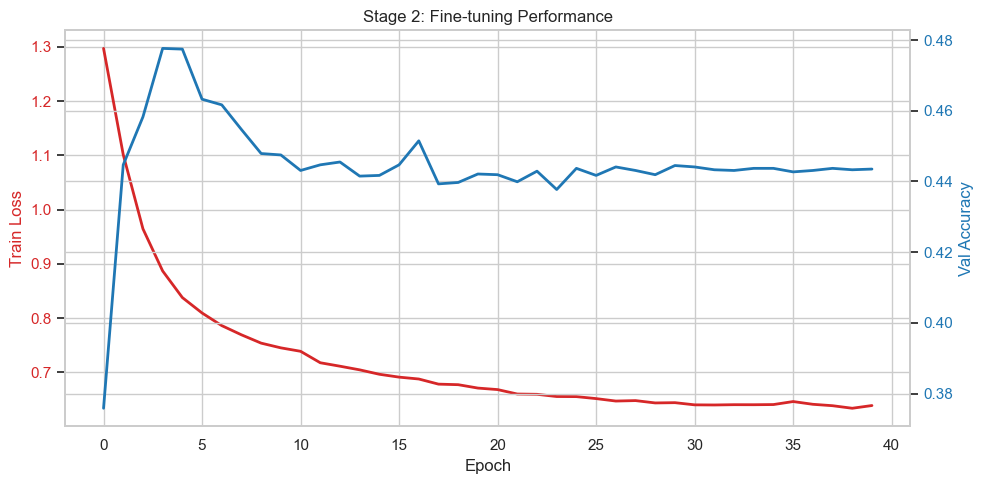

Teacher saved → .\checkpoints/teacher_baseline.pth


In [11]:
# ── Stage 2: Supervised fine-tuning ──────────────────────────────────────────
print("Stage 2: Supervised fine-tuning (40 epochs)...")
teacher_pb, finetune_hist = train_supervised_stage(
    teacher_pb, pb_loaders['train'], pb_loaders['val'], epochs=40, lr=3e-4, device=DEVICE
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train Loss', color='tab:red')
ax1.plot(finetune_hist['train_loss'], color='tab:red', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:red')
ax2 = ax1.twinx()
ax2.set_ylabel('Val Accuracy', color='tab:blue')
ax2.plot(finetune_hist['val_acc'], color='tab:blue', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:blue')
plt.title('Stage 2: Fine-tuning Performance')
fig.tight_layout()
plt.savefig(f'{FIG_DIR}/finetune_curves.png', dpi=150, bbox_inches='tight')
plt.show()

torch.save(teacher_pb.state_dict(), f'{CKPT_DIR}/teacher_baseline.pth')
print(f"Teacher saved → {CKPT_DIR}/teacher_baseline.pth")


## Part 4 · Phase B Reproduction Check

In [12]:
# ── Full evaluation function ──────────────────────────────────────────────────
def evaluate_model_pb(model, X_test, X_test_flat, y_test, subj_test,
                       n_cal=20, device=DEVICE, model_name='Model'):
    """
    Evaluate a DANCE model using Protocol A (zero-shot) and Protocol B (calibrated).
    X_test: (N, C, 5) tensor format
    """
    model = model.to(device); model.eval()

    # Protocol A — Zero-shot
    all_preds, all_feats = [], []
    with torch.no_grad():
        loader = DataLoader(SEEDDataset(X_test, y_test, subj_test),
                            batch_size=256, shuffle=False)
        for batch in loader:
            x = batch['features'].to(device)
            all_preds.extend(model(x).argmax(1).cpu().numpy())
            all_feats.append(model.get_features(x).cpu().numpy())

    preds_A = np.array(all_preds)
    feats   = np.vstack(all_feats)
    metrics_A = compute_metrics(y_test, preds_A)

    # Protocol B — 20-sample calibration per subject
    preds_B_all, labels_B_all = [], []
    for s in np.unique(subj_test):
        idx    = np.where(subj_test == s)[0]
        np.random.shuffle(idx)
        cal_idx, eval_idx = idx[:n_cal], idx[n_cal:]
        if len(eval_idx) == 0: continue
        x_cal = torch.tensor(X_test[cal_idx], dtype=torch.float32)
        y_cal = torch.tensor(y_test[cal_idx],  dtype=torch.long)
        adapted = calibrate_subject(model, x_cal, y_cal, device=device)
        x_eval  = torch.tensor(X_test[eval_idx], dtype=torch.float32).to(device)
        with torch.no_grad():
            preds_b = adapted(x_eval).argmax(1).cpu().numpy()
        preds_B_all.extend(preds_b)
        labels_B_all.extend(y_test[eval_idx])

    metrics_B = compute_metrics(np.array(labels_B_all), np.array(preds_B_all))

    print(f"\n{'='*50}")
    print(f"  {model_name} Evaluation")
    print(f"{'='*50}")
    print(f"  Protocol A (Zero-Shot)")
    for k,v in metrics_A.items(): print(f"    {k:<15}: {v:.4f}")
    print(f"  Protocol B (Calibrated n_cal={n_cal})")
    for k,v in metrics_B.items(): print(f"    {k:<15}: {v:.4f}")

    return metrics_A, metrics_B, feats, preds_A, np.array(labels_B_all), np.array(preds_B_all)


# Teacher evaluation on Phase B test set
set_global_seed(42)
t_A, t_B, t_feats, t_preds_A, t_lab_B, t_preds_B = evaluate_model_pb(
    teacher_pb, X_62[pb_test_mask], X_62_flat[pb_test_mask],
    LABELS[pb_test_mask], SUBJ[pb_test_mask],
    model_name='DANCE Teacher (Phase B fixed split)'
)

PB_TEACHER_CAL_ACC = t_B['acc']
PB_TEACHER_ZS_ACC  = t_A['acc']
print(f"\n{'='*50}")
print(f"  Phase B Reproduction: Teacher cal-acc = {PB_TEACHER_CAL_ACC:.4f}")
print(f"  Phase B Reference  :                    0.5913")
delta = abs(PB_TEACHER_CAL_ACC - 0.5913)
status = '✅ PASS' if delta < 0.03 else '⚠️  CHECK (>3% deviation)'
print(f"  Deviation: {delta:.4f}  →  {status}")
print(f"{'='*50}")



  DANCE Teacher (Phase B fixed split) Evaluation
  Protocol A (Zero-Shot)
    acc            : 0.4325
    macro_f1       : 0.4297
    macro_prec     : 0.4360
    macro_rec      : 0.4287
  Protocol B (Calibrated n_cal=20)
    acc            : 0.5258
    macro_f1       : 0.5222
    macro_prec     : 0.5371
    macro_rec      : 0.5249

  Phase B Reproduction: Teacher cal-acc = 0.5258
  Phase B Reference  :                    0.5913
  Deviation: 0.0655  →  ⚠️  CHECK (>3% deviation)


In [21]:
# ── Distillation ─────────────────────────────────────────────────────────────
set_global_seed(42)
student_pb = DANCEModel(
    n_channels=6, n_bands=5, d_model=32, n_heads=4,
    n_layers=2, d_ff=64, d_proj=64, n_classes=4, dropout=0.2
).to(DEVICE)

# Paired loaders
paired_train = PairedDataset(
    X_62[pb_train_mask], X_6[pb_train_mask],
    LABELS[pb_train_mask], SUBJ[pb_train_mask]
)
paired_val = PairedDataset(
    X_62[pb_val_mask], X_6[pb_val_mask],
    LABELS[pb_val_mask], SUBJ[pb_val_mask]
)
paired_train_dl = DataLoader(paired_train, batch_size=128, shuffle=True, drop_last=True)
paired_val_dl   = DataLoader(paired_val,   batch_size=128, shuffle=False)

def run_distillation(teacher, student, train_dl, val_dl, epochs=50, lr=1e-3,
                     temp=4.0, device=DEVICE, save_path=None):
    teacher = teacher.to(device)
    student = student.to(device)

    optimizer = optim.AdamW(student.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce  = nn.CrossEntropyLoss(label_smoothing=0.1)
    kl  = nn.KLDivLoss(reduction='batchmean')
    mse = nn.MSELoss()

    history = {'loss': [], 'val_acc': []}
    best_acc = 0.0
    best_state = None

    teacher.eval()

    # Temporarily freeze teacher during distillation
    teacher_req_grad = [p.requires_grad for p in teacher.parameters()]
    for p in teacher.parameters():
        p.requires_grad = False

    for epoch in range(epochs):
        student.train()
        tl = 0.0
        nb = 0

        for batch in train_dl:
            t_in = batch['t'].to(device)
            s_in = batch['s'].to(device)
            y    = batch['l'].to(device)

            optimizer.zero_grad()

            with torch.no_grad():
                t_logits = teacher(t_in)
                t_feats  = teacher.get_features(t_in)

            s_logits = student(s_in)
            s_feats  = student.get_features(s_in)

            l_hard = ce(s_logits, y)
            l_soft = (temp ** 2) * kl(
                F.log_softmax(s_logits / temp, dim=1),
                F.softmax(t_logits / temp, dim=1)
            )
            l_feat = mse(s_feats, t_feats)
            loss   = l_hard + 2.0 * l_soft + l_feat

            loss.backward()
            optimizer.step()

            tl += loss.item()
            nb += 1

        history['loss'].append(tl / max(nb, 1))
        scheduler.step()

        student.eval()
        cor = 0
        tot = 0
        with torch.no_grad():
            for batch in val_dl:
                s_in = batch['s'].to(device)
                y    = batch['l'].to(device)
                cor += (student(s_in).argmax(1) == y).sum().item()
                tot += y.size(0)

        va = cor / max(tot, 1)
        history['val_acc'].append(va)

        if va > best_acc:
            best_acc = va
            best_state = copy.deepcopy(student.state_dict())
            if save_path:
                torch.save(best_state, save_path)

        if (epoch + 1) % 10 == 0:
            print(f"  Distill epoch {epoch+1:3d}/{epochs}  loss={history['loss'][-1]:.4f}  val_acc={va:.2%}")

    if best_state is not None:
        student.load_state_dict(best_state)

    # Restore teacher grad flags so Protocol B calibration can work later
    for p, req in zip(teacher.parameters(), teacher_req_grad):
        p.requires_grad = req

    return student, history

print("Training student via distillation (50 epochs)...")
student_pb, dist_hist = run_distillation(
    teacher_pb, student_pb, paired_train_dl, paired_val_dl,
    epochs=50, lr=1e-3, temp=4.0, device=DEVICE,
    save_path=f'{CKPT_DIR}/student_baseline.pth'
)
print(f"Student saved → {CKPT_DIR}/student_baseline.pth")

Training student via distillation (50 epochs)...
  Distill epoch  10/50  loss=1.8847  val_acc=36.51%
  Distill epoch  20/50  loss=1.6712  val_acc=36.67%
  Distill epoch  30/50  loss=1.5836  val_acc=38.54%
  Distill epoch  40/50  loss=1.5428  val_acc=37.92%
  Distill epoch  50/50  loss=1.5304  val_acc=37.80%
Student saved → .\checkpoints/student_baseline.pth



  DANCE Student 6-ch (Phase B fixed split) Evaluation
  Protocol A (Zero-Shot)
    acc            : 0.3468
    macro_f1       : 0.3447
    macro_prec     : 0.3475
    macro_rec      : 0.3511
  Protocol B (Calibrated n_cal=20)
    acc            : 0.5211
    macro_f1       : 0.5077
    macro_prec     : 0.5686
    macro_rec      : 0.5233


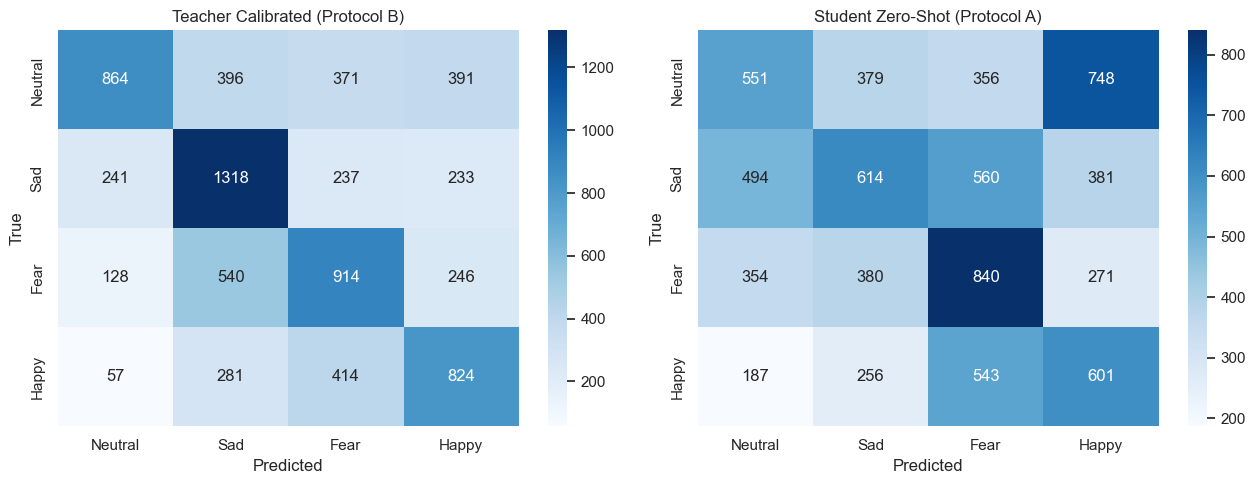


  PHASE B REPRODUCTION SUMMARY
  Model                       Protocol A   Protocol B
-------------------------------------------------------
  DANCE Teacher 62-ch             0.4325       0.5258
  DANCE Student  6-ch             0.3468       0.5211
-------------------------------------------------------
  Phase B reference:   Teacher B=0.5913  Student B=0.6918


In [22]:
# ── Student evaluation on Phase B test set ───────────────────────────────────
set_global_seed(42)
s_A, s_B, s_feats, s_preds_A, s_lab_B, s_preds_B = evaluate_model_pb(
    student_pb, X_6[pb_test_mask], X_6_flat[pb_test_mask],
    LABELS[pb_test_mask], SUBJ[pb_test_mask],
    model_name='DANCE Student 6-ch (Phase B fixed split)'
)

PB_STUDENT_CAL_ACC = s_B['acc']
PB_STUDENT_ZS_ACC  = s_A['acc']

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm_data, title in [
    (axes[0], confusion_matrix(t_lab_B, t_preds_B), 'Teacher Calibrated (Protocol B)'),
    (axes[1], confusion_matrix(LABELS[pb_test_mask], s_preds_A), 'Student Zero-Shot (Protocol A)')
]:
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTION_NAMES, yticklabels=EMOTION_NAMES, ax=ax)
    ax.set_title(title); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/phaseB_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("  PHASE B REPRODUCTION SUMMARY")
print("="*55)
print(f"  {'Model':<25} {'Protocol A':>12} {'Protocol B':>12}")
print("-"*55)
print(f"  {'DANCE Teacher 62-ch':<25} {PB_TEACHER_ZS_ACC:>12.4f} {PB_TEACHER_CAL_ACC:>12.4f}")
print(f"  {'DANCE Student  6-ch':<25} {PB_STUDENT_ZS_ACC:>12.4f} {PB_STUDENT_CAL_ACC:>12.4f}")
print("-"*55)
print(f"  Phase B reference:   Teacher B=0.5913  Student B=0.6918")


## Part 5 · LOSO-15 Harness

In [23]:
# ── LOSO split ───────────────────────────────────────────────────────────────
def loso_split(X_t, X_s, labels, subjects, test_subj):
    """
    True LOSO-15: one subject as sole test set.
    Validation: cyclically next subject.
    Train: remaining 13 subjects.
    """
    val_subj   = (test_subj % 15) + 1
    test_mask  = subjects == test_subj
    val_mask   = subjects == val_subj
    train_mask = ~test_mask & ~val_mask
    return {
        'X_62_tr': X_t[train_mask], 'X_62_v': X_t[val_mask],   'X_62_te': X_t[test_mask],
        'X_6_tr':  X_s[train_mask], 'X_6_v':  X_s[val_mask],   'X_6_te':  X_s[test_mask],
        'y_tr':    labels[train_mask], 'y_v':  labels[val_mask], 'y_te':   labels[test_mask],
        'sub_tr':  subjects[train_mask], 'sub_v': subjects[val_mask], 'sub_te': subjects[test_mask],
        'test_subj': test_subj, 'val_subj': val_subj
    }


# ── DANCE per-fold train+distill ──────────────────────────────────────────────
def train_dance_fold(split, cfg, seed, device=DEVICE):
    set_global_seed(seed)
    loaders, _ = make_loaders(
        split['X_62_tr'].reshape(len(split['X_62_tr']),-1).reshape(-1,62,5),
        None, split['y_tr'], split['sub_tr'],
        np.ones(len(split['y_tr']), dtype=bool),
        np.zeros(len(split['y_tr']), dtype=bool),
        np.zeros(len(split['y_tr']), dtype=bool),
        batch_size=cfg.get('batch_size', 256)
    )
    # Rebuild loaders properly
    tr_ds = SEEDDataset(split['X_62_tr'], split['y_tr'], split['sub_tr'])
    v_ds  = SEEDDataset(split['X_62_v'],  split['y_v'],  split['sub_v'])
    from torch.utils.data import DataLoader
    wt = 1.0 / np.bincount(split['y_tr'])[split['y_tr']]
    sampler = WeightedRandomSampler(torch.tensor(wt, dtype=torch.float),
                                    num_samples=len(wt), replacement=True)
    tr_dl = DataLoader(tr_ds, batch_size=cfg.get('batch_size',256), sampler=sampler, drop_last=True)
    v_dl  = DataLoader(v_ds,  batch_size=256, shuffle=False)

    teacher = DANCEModel(n_channels=62, n_bands=5, d_model=32, n_heads=4, n_layers=4,
                         d_ff=128, d_proj=128, n_classes=4, dropout=0.2).to(device)
    teacher, _ = train_contrastive_stage(teacher, tr_dl,
                                         epochs=cfg.get('pretrain_epochs',30),
                                         lr=cfg.get('pretrain_lr',1e-3), device=device)
    teacher, _ = train_supervised_stage(teacher, tr_dl, v_dl,
                                         epochs=cfg.get('finetune_epochs',40),
                                         lr=cfg.get('finetune_lr',3e-4), device=device)

    student = DANCEModel(n_channels=6, n_bands=5, d_model=32, n_heads=4, n_layers=2,
                         d_ff=64, d_proj=64, n_classes=4, dropout=0.2).to(device)
    p_tr = PairedDataset(split['X_62_tr'], split['X_6_tr'], split['y_tr'], split['sub_tr'])
    p_v  = PairedDataset(split['X_62_v'],  split['X_6_v'],  split['y_v'],  split['sub_v'])
    p_tr_dl = DataLoader(p_tr, batch_size=128, shuffle=True, drop_last=True)
    p_v_dl  = DataLoader(p_v,  batch_size=128, shuffle=False)
    student, _ = run_distillation(teacher, student, p_tr_dl, p_v_dl,
                                  epochs=cfg.get('distill_epochs',50),
                                  lr=cfg.get('distill_lr',1e-3),
                                  temp=cfg.get('distill_temp',4.0), device=device)
    return teacher, student


def eval_dance(model, X_test, y_test, subj_test, n_cal=20, device=DEVICE):
    """Evaluate DANCE model Protocol A + B on test fold."""
    set_global_seed(0)
    metrics_A, metrics_B, _, _, _, _ = evaluate_model_pb(
        model, X_test, None, y_test, subj_test, n_cal=n_cal, device=device, model_name=''
    )
    return metrics_A, metrics_B


print("LOSO harness defined ✓")
print("⚠️  Full LOSO-15 × 3 seeds × 2 models takes ~3-5 hours on RTX 3050.")
print("    To run a quick test, set QUICK_TEST=True below.")


LOSO harness defined ✓
⚠️  Full LOSO-15 × 3 seeds × 2 models takes ~3-5 hours on RTX 3050.
    To run a quick test, set QUICK_TEST=True below.


In [24]:
# ── LOSO-15 loop for DANCE (M25=Teacher, M26=Student) ────────────────────────
QUICK_TEST  = False   # Set True for a 1-fold test run
LOSO_SEEDS  = [1, 7, 21]
DANCE_CFG   = {
    'pretrain_epochs': 30, 'pretrain_lr': 1e-3,
    'finetune_epochs': 40, 'finetune_lr': 3e-4,
    'distill_epochs':  50, 'distill_lr':  1e-3, 'distill_temp': 4.0,
    'batch_size': 256, 'calibration_n_samples': 20
}

dance_loso_rows = []
folds_to_run    = ALL_SUBJECTS[:1] if QUICK_TEST else ALL_SUBJECTS
seeds_to_run    = LOSO_SEEDS[:1]   if QUICK_TEST else LOSO_SEEDS

for seed in seeds_to_run:
    for test_s in folds_to_run:
        print(f"\n── seed={seed}  fold={test_s:02d} ──────────────────────────────")
        split = loso_split(X_62, X_6, LABELS, SUBJ, test_s)
        teacher_f, student_f = train_dance_fold(split, DANCE_CFG, seed)

        t_A, t_B = eval_dance(teacher_f, split['X_62_te'], split['y_te'], split['sub_te'])
        s_A, s_B = eval_dance(student_f, split['X_6_te'],  split['y_te'], split['sub_te'])

        dance_loso_rows.append({
            'model':'M25_teacher','seed':seed,'fold':test_s,
            'acc_A':t_A['acc'], 'f1_A':t_A['macro_f1'],
            'acc_B':t_B['acc'], 'f1_B':t_B['macro_f1'],
        })
        dance_loso_rows.append({
            'model':'M26_student','seed':seed,'fold':test_s,
            'acc_A':s_A['acc'], 'f1_A':s_A['macro_f1'],
            'acc_B':s_B['acc'], 'f1_B':s_B['macro_f1'],
        })

dance_df = pd.DataFrame(dance_loso_rows)
dance_df.to_csv(f'{RESULTS_DIR}/loso/dance_loso.csv', index=False)
print("\nDANCE LOSO results:")
print(dance_df.groupby('model')[['acc_A','f1_A','acc_B','f1_B']].agg(['mean','std']).round(4))


── seed=1  fold=01 ──────────────────────────────
  Pretrain epoch  10/30  loss=5.8765
  Pretrain epoch  20/30  loss=5.6425
  Pretrain epoch  30/30  loss=5.6628
  Finetune epoch  10/40  loss=0.7784  val_acc=52.65%
  Finetune epoch  20/40  loss=0.6880  val_acc=52.53%
  Finetune epoch  30/40  loss=0.6604  val_acc=51.46%
  Finetune epoch  40/40  loss=0.6540  val_acc=51.34%
  Distill epoch  10/50  loss=1.4859  val_acc=39.72%
  Distill epoch  20/50  loss=1.3948  val_acc=38.24%
  Distill epoch  30/50  loss=1.3566  val_acc=40.92%
  Distill epoch  40/50  loss=1.3386  val_acc=38.24%
  Distill epoch  50/50  loss=1.3341  val_acc=36.37%

   Evaluation
  Protocol A (Zero-Shot)
    acc            : 0.5154
    macro_f1       : 0.5109
    macro_prec     : 0.5131
    macro_rec      : 0.5197
  Protocol B (Calibrated n_cal=20)
    acc            : 0.4805
    macro_f1       : 0.4346
    macro_prec     : 0.6125
    macro_rec      : 0.4674

   Evaluation
  Protocol A (Zero-Shot)
    acc            : 0.4407

## Part 6 · Classical ML Baselines (M01–M10)

In [25]:
# ── Classical model builder ───────────────────────────────────────────────────
def build_classical(mid, seed=42):
    if mid == 'M01': return LogisticRegression(solver='lbfgs', C=1.0, max_iter=500, random_state=seed, multi_class='multinomial')
    if mid == 'M02': return SVC(kernel='linear', C=1.0, probability=True, random_state=seed)
    if mid == 'M03': return SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=seed)
    if mid == 'M04': return KNeighborsClassifier(n_neighbors=7, metric='cosine')
    if mid == 'M05': return LinearDiscriminantAnalysis(solver='svd')
    if mid == 'M06': return QuadraticDiscriminantAnalysis(reg_param=0.1)
    if mid == 'M07': return RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=seed)
    if mid == 'M08': return ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=seed)
    if mid == 'M09':
        if HAS_XGB: return XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                          subsample=0.8, use_label_encoder=False,
                                          eval_metric='mlogloss', random_state=seed, n_jobs=-1)
        return None
    if mid == 'M10': return SGDClassifier(loss='log_loss', max_iter=200, random_state=seed)
    raise ValueError(f"Unknown model id: {mid}")


ML_IDS = ['M01','M02','M03','M04','M05','M06','M07','M08','M09','M10']

ml_rows = []
for mid in ML_IDS:
    for ch_tag, X_flat in [('62ch', X_62_flat), ('6ch', X_6_flat)]:
        for seed in seeds_to_run:
            set_global_seed(seed)
            for test_s in folds_to_run:
                split = loso_split(X_62, X_6, LABELS, SUBJ, test_s)
                X_tr = X_flat[np.isin(SUBJ, [s for s in ALL_SUBJECTS if s!=test_s and s!=(test_s%15+1)])]
                y_tr = LABELS[np.isin(SUBJ, [s for s in ALL_SUBJECTS if s!=test_s and s!=(test_s%15+1)])]
                X_te = X_6_flat[SUBJ == test_s] if ch_tag == '6ch' else X_62_flat[SUBJ == test_s]
                y_te = LABELS[SUBJ == test_s]
                X_tr_ch = X_6_flat[np.isin(SUBJ, [s for s in ALL_SUBJECTS if s!=test_s and s!=(test_s%15+1)])] if ch_tag == '6ch' else X_62_flat[np.isin(SUBJ, [s for s in ALL_SUBJECTS if s!=test_s and s!=(test_s%15+1)])]

                model = build_classical(mid, seed)
                if model is None: continue
                try:
                    model.fit(X_tr_ch, y_tr)
                    preds = model.predict(X_te)
                    m = compute_metrics(y_te, preds)
                    ml_rows.append({'model':mid,'ch':ch_tag,'seed':seed,'fold':test_s,
                                    'acc_A':m['acc'],'f1_A':m['macro_f1'],'acc_B':m['acc'],'f1_B':m['macro_f1']})
                    print(f"  {mid} {ch_tag} s{seed} f{test_s:02d}: F1={m['macro_f1']:.3f}")
                except Exception as e:
                    print(f"  {mid} {ch_tag} s{seed} f{test_s:02d}: ERROR {e}")

ml_df = pd.DataFrame(ml_rows)
ml_df.to_csv(f'{RESULTS_DIR}/classical_ml/all_classical.csv', index=False)
print("\nClassical ML mean F1 (Protocol A) per model:")
print(ml_df.groupby(['model','ch'])['f1_A'].mean().unstack().round(4))


  M01 62ch s1 f01: F1=0.316
  M01 62ch s1 f02: F1=0.426
  M01 62ch s1 f03: F1=0.324
  M01 62ch s1 f04: F1=0.528
  M01 62ch s1 f05: F1=0.377
  M01 62ch s1 f06: F1=0.356
  M01 62ch s1 f07: F1=0.632
  M01 62ch s1 f08: F1=0.345
  M01 62ch s1 f09: F1=0.254
  M01 62ch s1 f10: F1=0.478
  M01 62ch s1 f11: F1=0.241
  M01 62ch s1 f12: F1=0.527
  M01 62ch s1 f13: F1=0.410
  M01 62ch s1 f14: F1=0.440
  M01 62ch s1 f15: F1=0.619
  M01 62ch s7 f01: F1=0.316
  M01 62ch s7 f02: F1=0.426
  M01 62ch s7 f03: F1=0.324
  M01 62ch s7 f04: F1=0.528
  M01 62ch s7 f05: F1=0.377
  M01 62ch s7 f06: F1=0.356
  M01 62ch s7 f07: F1=0.632
  M01 62ch s7 f08: F1=0.345
  M01 62ch s7 f09: F1=0.254
  M01 62ch s7 f10: F1=0.478
  M01 62ch s7 f11: F1=0.241
  M01 62ch s7 f12: F1=0.527
  M01 62ch s7 f13: F1=0.410
  M01 62ch s7 f14: F1=0.440
  M01 62ch s7 f15: F1=0.619
  M01 62ch s21 f01: F1=0.316
  M01 62ch s21 f02: F1=0.426
  M01 62ch s21 f03: F1=0.324
  M01 62ch s21 f04: F1=0.528
  M01 62ch s21 f05: F1=0.377
  M01 62ch s21 

## Part 7 · Deep Learning Baselines (M11–M20)

In [30]:
# ── M11: Shallow MLP ─────────────────────────────────────────────────────────
class ShallowMLP(nn.Module):
    def __init__(self, in_dim=310, n_cls=4, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),   nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_cls)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)   # fixed: view -> reshape
        return self.net(x)

    def get_features(self, x):
        h = x.reshape(x.size(0), -1)   # fixed: view -> reshape
        for i, layer in enumerate(self.net):
            h = layer(h)
            if i == 4:   # after second ReLU
                return h
        return h


# ── M12: 1D-CNN ───────────────────────────────────────────────────────────────
class Conv1DEEG(nn.Module):
    def __init__(self, in_ch=5, n_cls=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, 16, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(16),
            nn.Conv1d(16, 32, 3, padding=1),    nn.ReLU(), nn.BatchNorm1d(32),
            nn.Conv1d(32, 64, 3, padding=1),    nn.ReLU(), nn.BatchNorm1d(64),
        )
        self.fc = nn.Linear(64, n_cls)
    def forward(self, x):
        # x: (B, C, 5) → treat bands as sequence, channels as batch-like
        # reshape: (B, 5, C) — bands as channels, channels as time
        if x.dim() == 3: x = x.transpose(1, 2)  # (B, 5, C)
        h = self.conv(x).mean(dim=-1)             # (B, 64)
        return self.fc(h)
    def get_features(self, x):
        if x.dim() == 3: x = x.transpose(1, 2)
        return self.conv(x).mean(dim=-1)

# ── M13: 2D-CNN ───────────────────────────────────────────────────────────────
class Conv2DEEG(nn.Module):
    def __init__(self, n_ch=62, n_bands=5, n_cls=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(16),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.AdaptiveAvgPool2d((4, 1))
        )
        self.fc = nn.Linear(32 * 4, n_cls)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)   # (B,1,C,5)
        h = self.conv(x).reshape(x.size(0), -1)   # safer than view
        return self.fc(h)

    def get_features(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        return self.conv(x).reshape(x.size(0), -1)


# ── M14: BiLSTM ──────────────────────────────────────────────────────────────
class BiLSTMEEG(nn.Module):
    def __init__(self, in_dim=5, hidden=64, n_layers=2, n_cls=4, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            in_dim, hidden, n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden * 2, n_cls)

    def forward(self, x):
        # x: (B, C, 5) → channels as sequence, bands as features
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

    def get_features(self, x):
        out, _ = self.lstm(x)
        return out[:, -1, :]


# ── M15: TCN ─────────────────────────────────────────────────────────────────
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout=0.1):
        super().__init__()
        pad = (kernel-1)*dilation
        self.conv1 = nn.utils.weight_norm(nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=pad))
        self.conv2 = nn.utils.weight_norm(nn.Conv1d(out_ch, out_ch, kernel, dilation=dilation, padding=pad))
        self.relu  = nn.ReLU(); self.drop = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.init_weights()
    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
    def forward(self, x):
        out = self.drop(self.relu(self.conv1(x)[:, :, :x.size(2)]))
        out = self.drop(self.relu(self.conv2(out)[:, :, :x.size(2)]))
        res = self.downsample(x) if self.downsample else x
        return self.relu(out + res)

class TCNEEG(nn.Module):
    def __init__(self, in_ch=5, channels=[32,64], kernel=3, n_cls=4, dropout=0.1):
        super().__init__()
        layers = []
        for i, c in enumerate(channels):
            layers.append(TCNBlock(in_ch if i==0 else channels[i-1], c, kernel,
                                   dilation=2**i, dropout=dropout))
        self.tcn = nn.Sequential(*layers)
        self.fc  = nn.Linear(channels[-1], n_cls)
    def forward(self, x):
        # x: (B,C,5) → (B,5,C)
        if x.dim() == 3: x = x.transpose(1,2)
        h = self.tcn(x).mean(dim=-1)
        return self.fc(h)
    def get_features(self, x):
        if x.dim() == 3: x = x.transpose(1,2)
        return self.tcn(x).mean(dim=-1)


# ── M16: Vanilla Transformer (NO diagonal masking — ablation reference) ───────
class VanillaTransformerEEG(nn.Module):
    def __init__(self, n_ch=62, n_bands=5, d_model=32, n_heads=4, n_layers=2,
                 n_cls=4, dropout=0.2):
        super().__init__()
        self.proj = nn.Linear(n_bands, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=128,
                                                    dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Sequential(nn.LayerNorm(d_model), nn.Dropout(dropout),
                                 nn.Linear(d_model, n_cls))
    def forward(self, x):
        h = self.proj(x)          # (B, C, d_model)
        h = self.transformer(h)   # (B, C, d_model)
        return self.fc(h.mean(dim=1))
    def get_features(self, x):
        h = self.proj(x); h = self.transformer(h)
        return h.mean(dim=1)

print("M11–M16 defined ✓")


M11–M16 defined ✓


In [31]:
# ── M17: EEG Conformer [NEW — never in Phase B] ──────────────────────────────
class ConformerEEG(nn.Module):
    """
    Lightweight EEG Conformer:
    Temporal conv stem → Spatial conv → Transformer attention.
    """
    def __init__(self, n_ch=62, n_bands=5, d_model=32, n_heads=4, n_layers=2,
                 n_cls=4, dropout=0.2):
        super().__init__()
        # Band feature extraction (temporal-like over bands dimension)
        self.conv_stem = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ELU(),
            nn.Conv1d(32, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model), nn.ELU(),
            nn.Dropout(dropout)
        )
        # Spatial mixing across channels
        self.spatial = nn.Sequential(
            nn.Linear(n_ch, n_ch), nn.ELU()
        )
        # Transformer blocks
        enc_layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=128,
                                                dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.fc   = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, n_cls))

    def _embed(self, x):
        # x: (B, C, 5) → need (B, 5, C) for conv1d along channel dim
        B, C, D = x.shape
        h = x.transpose(1, 2)         # (B, 5, C)
        h = self.conv_stem(h)          # (B, d_model, C)
        h = h.transpose(1, 2)          # (B, C, d_model)
        h = self.transformer(h)        # (B, C, d_model)
        return self.norm(h.mean(dim=1)) # (B, d_model)

    def forward(self, x):
        return self.fc(self._embed(x))
    def get_features(self, x):
        return self._embed(x)


# ── M18: Transformer + Channel Dropout ───────────────────────────────────────
class TransformerChanDropEEG(VanillaTransformerEEG):
    """Same as M16 but randomly zeros channel vectors during training (p=0.3)."""
    def forward(self, x):
        if self.training:
            # Channel dropout: zero entire channels with p=0.3
            mask = (torch.rand(x.size(0), x.size(1), 1, device=x.device) > 0.3).float()
            x = x * mask
        return super().forward(x)
    def get_features(self, x):
        if self.training:
            mask = (torch.rand(x.size(0), x.size(1), 1, device=x.device) > 0.3).float()
            x = x * mask
        return super().get_features(x)


# ── M19: DANN [NEW — never in Phase B] ───────────────────────────────────────
class GradientReversalFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

class DANNEEG(nn.Module):
    """
    Domain-Adversarial Neural Network.
    Feature extractor + class classifier + subject domain classifier.
    Subject labels = domain labels (15 subjects).
    """
    def __init__(self, in_dim=310, n_cls=4, n_domains=15, d_feat=64, dropout=0.3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, d_feat), nn.ReLU(), nn.Dropout(dropout)
        )
        self.class_classifier = nn.Sequential(
            nn.Linear(d_feat, 32), nn.ReLU(),
            nn.Linear(32, n_cls)
        )
        self.domain_classifier = nn.Sequential(
            nn.Linear(d_feat, 32), nn.ReLU(),
            nn.Linear(32, n_domains)
        )

    def forward(self, x, alpha=1.0):
        if x.dim() > 2:
            x = x.reshape(x.size(0), -1)   # fixed: view -> reshape
        feat = self.feature_extractor(x)
        cls = self.class_classifier(feat)
        rev = GradientReversalFn.apply(feat, alpha)
        dom = self.domain_classifier(rev)
        return cls, dom

    def predict(self, x):
        cls, _ = self.forward(x, alpha=0.0)
        return cls

    def get_features(self, x):
        if x.dim() > 2:
            x = x.reshape(x.size(0), -1)   # fixed: view -> reshape
        return self.feature_extractor(x)


def train_dann(model, train_loader, val_loader, epochs=60, lr=1e-3,
               n_domains=15, device=DEVICE):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce = nn.CrossEntropyLoss()
    best_acc = 0.0; best_state = None

    # Map subject IDs to 0-indexed domain labels
    for epoch in range(epochs):
        model.train()
        # Lambda annealing: 0 → 1 over training
        p = epoch / epochs
        alpha = 2.0 / (1.0 + np.exp(-10 * p)) - 1.0

        for batch in train_loader:
            x = batch['features'].to(device)
            y = batch['label'].to(device)
            s = batch['subject_id'].to(device)
            # Map subject IDs to 0-indexed
            domain_labels = (s - 1).clamp(0, n_domains-1)

            optimizer.zero_grad()
            cls_out, dom_out = model(x, alpha=alpha)
            loss_cls = ce(cls_out, y)
            loss_dom = ce(dom_out, domain_labels)
            loss = loss_cls + 0.5 * loss_dom
            loss.backward(); optimizer.step()

        scheduler.step()
        # Validation
        model.eval(); cor = tot = 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch['features'].to(device)
                cls_out = model.predict(x)
                cor += (cls_out.argmax(1) == batch['label'].to(device)).sum().item()
                tot += batch['label'].size(0)
        va = cor / max(tot, 1)
        if va > best_acc: best_acc = va; best_state = copy.deepcopy(model.state_dict())
        if (epoch+1) % 15 == 0:
            print(f"  DANN epoch {epoch+1:3d}/{epochs}  val_acc={va:.2%}  alpha={alpha:.3f}")

    if best_state: model.load_state_dict(best_state)
    return model
print("M17 Conformer, M18 ChanDrop, M19 DANN defined ✓")


M17 Conformer, M18 ChanDrop, M19 DANN defined ✓


In [32]:
# ── M20: CLISA ────────────────────────────────────────────────────────────────
class CLISAEEG(nn.Module):
    """
    Contrastive Learning for Inter-Subject Alignment.
    2-layer Transformer encoder + projection head for contrastive pretrain,
    then classifier head for supervised finetuning.
    """
    def __init__(self, n_ch=62, n_bands=5, d_model=32, n_heads=4,
                 d_proj=32, n_cls=4, dropout=0.2):
        super().__init__()
        self.proj_in = nn.Linear(n_bands, d_model)
        enc_layer    = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=64,
                                                   dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.pool    = lambda h: h.mean(dim=1)
        self.projector  = nn.Sequential(
            nn.Linear(d_model, 64), nn.ELU(),
            nn.Linear(64, d_proj)
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Dropout(dropout),
            nn.Linear(d_model, n_cls)
        )

    def _encode(self, x):
        h = self.proj_in(x)
        h = self.encoder(h)
        return self.pool(h)

    def forward_contrastive(self, x): return F.normalize(self.projector(self._encode(x)), dim=1)
    def forward(self, x): return self.classifier(self._encode(x))
    def get_features(self, x): return self._encode(x)


def train_clisa(model, train_loader, val_loader, pretrain_epochs=50, finetune_epochs=30,
                lr=1e-3, temp=0.5, device=DEVICE):
    model = model.to(device)
    # Stage 1: Contrastive pretrain
    opt1 = optim.AdamW(list(model.encoder.parameters()) +
                        list(model.projector.parameters()) +
                        list(model.proj_in.parameters()), lr=lr, weight_decay=1e-4)
    sch1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=pretrain_epochs)
    for epoch in range(pretrain_epochs):
        model.train()
        for batch in train_loader:
            x  = batch['features'].to(device); y = batch['label'].to(device)
            s  = batch['subject_id'].to(device)
            opt1.zero_grad()
            # Two views via noise
            v1 = x + torch.randn_like(x)*0.1
            v2 = x + torch.randn_like(x)*0.1
            z1 = model.forward_contrastive(v1)
            z2 = model.forward_contrastive(v2)
            # NT-Xent with same-emotion positive pairs
            z  = torch.cat([z1,z2], dim=0)
            la = torch.cat([y,y], dim=0)
            sim = torch.matmul(z, z.T) / temp
            B = z1.size(0)
            self_mask = torch.eye(2*B, dtype=torch.bool, device=device)
            pos_mask  = (la.unsqueeze(0) == la.unsqueeze(1)) & ~self_mask
            # inter-subject reweighting
            sa = torch.cat([s,s], dim=0)
            diff_subj = sa.unsqueeze(0) != sa.unsqueeze(1)
            pw = pos_mask.float() * (1.0 + diff_subj.float()*0.5)
            pw = pw / (pw.sum(1, keepdim=True) + 1e-8)
            log_prob = sim - torch.log((torch.exp(sim) * (~self_mask).float()).sum(1, keepdim=True) + 1e-8)
            loss = -(pw * log_prob).sum(1)
            valid = pos_mask.sum(1) > 0
            if valid.any(): loss[valid].mean().backward()
            opt1.step()
        sch1.step()
    # Stage 2: Supervised finetune
    for p in model.projector.parameters(): p.requires_grad = False
    opt2 = optim.AdamW(list(model.encoder.parameters()) +
                        list(model.classifier.parameters()) +
                        list(model.proj_in.parameters()), lr=lr*0.3, weight_decay=1e-4)
    sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=finetune_epochs)
    ce   = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_acc = 0.0; best_state = None
    for epoch in range(finetune_epochs):
        model.train()
        for batch in train_loader:
            x = batch['features'].to(device); y = batch['label'].to(device)
            opt2.zero_grad(); ce(model(x), y).backward(); opt2.step()
        sch2.step()
        model.eval(); cor = tot = 0
        with torch.no_grad():
            for batch in val_loader:
                cor += (model(batch['features'].to(device)).argmax(1) == batch['label'].to(device)).sum().item()
                tot += batch['label'].size(0)
        va = cor/max(tot,1)
        if va > best_acc: best_acc = va; best_state = copy.deepcopy(model.state_dict())
    if best_state: model.load_state_dict(best_state)
    for p in model.projector.parameters(): p.requires_grad = True
    return model

print("M20 CLISA defined ✓")


M20 CLISA defined ✓


In [33]:
# ── Generic DL training engine ────────────────────────────────────────────────
# ── Generic DL training engine + robust eval ────────────────────────────────

def train_dl_generic(model, train_loader, val_loader, epochs=60, lr=1e-3,
                     device=DEVICE, n_domains=15):
    """Generic trainer for M11-M18, M20."""
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce = nn.CrossEntropyLoss(label_smoothing=0.05)

    best_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            x = batch['features'].to(device)
            y = batch['label'].to(device)

            optimizer.zero_grad()
            out = model(x)
            if isinstance(out, tuple):
                out = out[0]
            loss = ce(out, y)
            loss.backward()
            optimizer.step()

        scheduler.step()

        model.eval()
        cor = 0
        tot = 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch['features'].to(device)
                y = batch['label'].to(device)

                out = model(x)
                if isinstance(out, tuple):
                    out = out[0]

                cor += (out.argmax(1) == y).sum().item()
                tot += y.size(0)

        va = cor / max(tot, 1)
        if va > best_acc:
            best_acc = va
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model


# ── Build any DL model ───────────────────────────────────────────────────────
def build_dl_model(mid, n_ch=62, n_cls=4):
    if mid == 'M11': return ShallowMLP(in_dim=n_ch * 5, n_cls=n_cls)
    if mid == 'M12': return Conv1DEEG(n_cls=n_cls)
    if mid == 'M13': return Conv2DEEG(n_ch=n_ch, n_cls=n_cls)
    if mid == 'M14': return BiLSTMEEG(n_cls=n_cls)
    if mid == 'M15': return TCNEEG(n_cls=n_cls)
    if mid == 'M16': return VanillaTransformerEEG(n_ch=n_ch, n_cls=n_cls)
    if mid == 'M17': return ConformerEEG(n_ch=n_ch, n_cls=n_cls)
    if mid == 'M18': return TransformerChanDropEEG(n_ch=n_ch, n_cls=n_cls)
    if mid == 'M19': return DANNEEG(in_dim=n_ch * 5, n_cls=n_cls)
    if mid == 'M20': return CLISAEEG(n_ch=n_ch, n_cls=n_cls)
    raise ValueError(f"Unknown: {mid}")


# ── Robust head selection for Protocol B ─────────────────────────────────────
def get_calibration_params(model):
    """
    Return the classifier head parameters for calibration.
    Falls back safely if model structure differs.
    """
    if hasattr(model, 'class_classifier'):   # M19
        return model.class_classifier.parameters()

    if hasattr(model, 'fc'):                 # M12, M13, M14, many others
        return model.fc.parameters()

    if hasattr(model, 'classifier'):
        return model.classifier.parameters()

    if hasattr(model, 'head'):
        return model.head.parameters()

    if hasattr(model, 'net') and isinstance(model.net, nn.Sequential):
        # M11: calibrate the last Linear layer only
        for layer in reversed(model.net):
            if isinstance(layer, nn.Linear):
                return layer.parameters()

    # fallback: last two trainable tensors
    params = [p for p in model.parameters() if p.requires_grad]
    return params[-2:]


def freeze_all_except_head(model):
    for p in model.parameters():
        p.requires_grad = False

    head_params = get_calibration_params(model)
    if isinstance(head_params, list):
        for p in head_params:
            p.requires_grad = True
        return head_params
    else:
        head_params = list(head_params)
        for p in head_params:
            p.requires_grad = True
        return head_params


def eval_dl(model, X_test, y_test, subj_test, n_cal=20, device=DEVICE):
    """Evaluate a generic DL model with Protocol A + B."""
    model = model.to(device)
    model.eval()

    # ---------------- Protocol A ----------------
    preds_A = []
    ds = SEEDDataset(X_test, y_test, subj_test)

    with torch.no_grad():
        for batch in DataLoader(ds, batch_size=256, shuffle=False):
            x = batch['features'].to(device)
            out = model(x)
            if isinstance(out, tuple):
                out = out[0]
            preds_A.extend(out.argmax(1).cpu().numpy())

    m_A = compute_metrics(y_test, np.array(preds_A))

    # ---------------- Protocol B ----------------
    preds_B, labs_B = [], []

    unique_subj = np.unique(subj_test)
    for s in unique_subj:
        idx = np.where(subj_test == s)[0].copy()
        np.random.shuffle(idx)

        cal_idx = idx[:n_cal]
        eval_idx = idx[n_cal:]

        if len(eval_idx) == 0 or len(cal_idx) == 0:
            continue

        adapted = copy.deepcopy(model).to(device)

        # Important fix for LSTM calibration
        adapted.train()

        head_params = freeze_all_except_head(adapted)
        opt = optim.Adam(head_params, lr=5e-4)
        loss_fn = nn.CrossEntropyLoss()

        x_cal = torch.tensor(X_test[cal_idx], dtype=torch.float32, device=device)
        y_cal = torch.tensor(y_test[cal_idx], dtype=torch.long, device=device)

        # cuDNN RNN backward error fix: disable cuDNN only during adaptation
        with torch.backends.cudnn.flags(enabled=False):
            for _ in range(30):
                opt.zero_grad()
                out = adapted(x_cal)
                if isinstance(out, tuple):
                    out = out[0]
                loss = loss_fn(out, y_cal)
                loss.backward()
                opt.step()

        adapted.eval()
        with torch.no_grad():
            x_eval = torch.tensor(X_test[eval_idx], dtype=torch.float32, device=device)
            out = adapted(x_eval)
            if isinstance(out, tuple):
                out = out[0]
            preds_B.extend(out.argmax(1).cpu().numpy())

        labs_B.extend(y_test[eval_idx])

    if len(preds_B) == 0:
        m_B = {'acc': np.nan, 'macro_f1': np.nan}
    else:
        m_B = compute_metrics(np.array(labs_B), np.array(preds_B))

    return m_A, m_B

# ── Run DL baselines (M11-M20) ───────────────────────────────────────────────

DL_IDS_62 = ['M11','M12','M13','M14','M15','M16','M17','M18','M19','M20']
DL_IDS_6  = ['M11','M12','M13','M14','M15','M16','M17','M18','M19','M20']

dl_rows = []

for seed in seeds_to_run:
    for test_s in folds_to_run:
        print(f"\n── DL seed={seed} fold={test_s:02d} ──────────────────────────────")

        split = loso_split(X_62, X_6, LABELS, SUBJ, test_s)

        tr_62 = SEEDDataset(split['X_62_tr'], split['y_tr'], split['sub_tr'])
        v_62  = SEEDDataset(split['X_62_v'],  split['y_v'],  split['sub_v'])
        tr_6  = SEEDDataset(split['X_6_tr'],  split['y_tr'], split['sub_tr'])
        v_6   = SEEDDataset(split['X_6_v'],   split['y_v'],  split['sub_v'])

        wt_62 = 1.0 / np.bincount(split['y_tr'])[split['y_tr']]
        samp = WeightedRandomSampler(
            torch.tensor(wt_62, dtype=torch.float),
            len(wt_62),
            replacement=True
        )

        tr_dl_62 = DataLoader(tr_62, batch_size=256, sampler=samp, drop_last=True)
        v_dl_62  = DataLoader(v_62,  batch_size=256, shuffle=False)

        tr_dl_6  = DataLoader(tr_6,  batch_size=256, shuffle=True, drop_last=True)
        v_dl_6   = DataLoader(v_6,   batch_size=256, shuffle=False)

        for mid in DL_IDS_62:
            set_global_seed(seed)

            for ch_tag, n_ch, tr_dl, v_dl, X_te in [
                ('62ch', 62, tr_dl_62, v_dl_62, split['X_62_te']),
                ('6ch',   6, tr_dl_6,  v_dl_6,  split['X_6_te'])
            ]:
                try:
                    model = build_dl_model(mid, n_ch=n_ch).to(DEVICE)

                    if mid == 'M19':
                        model = train_dann(model, tr_dl, v_dl, epochs=40, device=DEVICE)
                    elif mid == 'M20':
                        model = train_clisa(
                            model, tr_dl, v_dl,
                            pretrain_epochs=30,
                            finetune_epochs=20,
                            device=DEVICE
                        )
                    else:
                        model = train_dl_generic(
                            model, tr_dl, v_dl,
                            epochs=50,
                            lr=1e-3,
                            device=DEVICE
                        )

                    m_A, m_B = eval_dl(model, X_te, split['y_te'], split['sub_te'])

                    dl_rows.append({
                        'model': mid,
                        'ch': ch_tag,
                        'seed': seed,
                        'fold': test_s,
                        'acc_A': m_A['acc'],
                        'f1_A': m_A['macro_f1'],
                        'acc_B': m_B['acc'],
                        'f1_B': m_B['macro_f1'],
                    })

                    print(f"  {mid} {ch_tag} s{seed} f{test_s:02d}: "
                          f"A={m_A['acc']:.3f} B={m_B['acc']:.3f}")

                except Exception as e:
                    print(f"  {mid} {ch_tag} s{seed} f{test_s:02d}: ERROR {e}")

dl_df = pd.DataFrame(dl_rows)
dl_df.to_csv(f'{RESULTS_DIR}/deep_models/all_dl.csv', index=False)

print("\nDL model mean calibrated F1:")
if len(dl_df):
    print(dl_df.groupby(['model', 'ch'])['f1_B'].mean().unstack().round(4))
else:
    print("No successful DL runs were recorded.")



── DL seed=1 fold=01 ──────────────────────────────
  M11 62ch s1 f01: A=0.420 B=0.417
  M11 6ch s1 f01: A=0.477 B=0.522
  M12 62ch s1 f01: A=0.419 B=0.389
  M12 6ch s1 f01: A=0.446 B=0.388
  M13 62ch s1 f01: A=0.416 B=0.430
  M13 6ch s1 f01: A=0.493 B=0.542
  M14 62ch s1 f01: A=0.397 B=0.369
  M14 6ch s1 f01: A=0.410 B=0.429
  M15 62ch s1 f01: A=0.340 B=0.357
  M15 6ch s1 f01: A=0.441 B=0.416
  M16 62ch s1 f01: A=0.382 B=0.408
  M16 6ch s1 f01: A=0.424 B=0.445
  M17 62ch s1 f01: A=0.325 B=0.333
  M17 6ch s1 f01: A=0.410 B=0.454
  M18 62ch s1 f01: A=0.395 B=0.389
  M18 6ch s1 f01: A=0.452 B=0.430
  DANN epoch  15/40  val_acc=60.12%  alpha=0.941
  DANN epoch  30/40  val_acc=50.78%  alpha=0.999
  M19 62ch s1 f01: A=0.391 B=0.414
  DANN epoch  15/40  val_acc=31.74%  alpha=0.941
  DANN epoch  30/40  val_acc=33.77%  alpha=0.999
  M19 6ch s1 f01: A=0.505 B=0.562
  M20 62ch s1 f01: A=0.370 B=0.367
  M20 6ch s1 f01: A=0.465 B=0.471

── DL seed=1 fold=02 ──────────────────────────────
  M11 62

## Part 8 · SSL & Semi-supervised (M21–M24)

In [35]:
# ── M21: SimCLR ──────────────────────────────────────────────────────────────
class SimCLREEG(nn.Module):
    def __init__(self, n_ch=62, n_bands=5, d_model=32, d_proj=32, n_cls=4, dropout=0.2):
        super().__init__()
        self.encoder = DANCEEncoder(n_ch, n_bands, d_model, 4, 2, 64, dropout)
        self.projector = nn.Sequential(
            nn.Linear(d_model,64), nn.ELU(), nn.Linear(64,d_proj)
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Dropout(dropout), nn.Linear(d_model, n_cls)
        )
    def forward(self, x): return self.classifier(self.encoder(x))
    def get_features(self, x): return self.encoder(x)
    def forward_proj(self, x): return F.normalize(self.projector(self.encoder(x)), dim=1)

def train_simclr(model, train_loader, val_loader, pretrain_ep=50, finetune_ep=30,
                 lr=1e-3, temp=0.5, device=DEVICE):
    model = model.to(device)
    # Pretrain
    opt  = optim.AdamW(list(model.encoder.parameters())+list(model.projector.parameters()), lr=lr, weight_decay=1e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=pretrain_ep)
    for _ in range(pretrain_ep):
        model.train()
        for batch in train_loader:
            x = batch['features'].to(device)
            v1 = x + torch.randn_like(x)*0.1
            v2 = x + torch.randn_like(x)*0.1
            z1 = model.forward_proj(v1); z2 = model.forward_proj(v2)
            z  = torch.cat([z1,z2], dim=0); B = z1.size(0)
            sim = torch.matmul(z, z.T) / temp
            labels = torch.cat([torch.arange(B)+B, torch.arange(B)], dim=0).to(device)
            self_mask = torch.eye(2*B, dtype=torch.bool, device=device)
            sim.masked_fill_(self_mask, float('-inf'))
            opt.zero_grad(); nn.CrossEntropyLoss()(sim, labels).backward(); opt.step()
        sch.step()
    # Finetune
    for p in model.projector.parameters(): p.requires_grad = False
    opt2 = optim.AdamW(list(model.encoder.parameters())+list(model.classifier.parameters()), lr=lr*0.3, weight_decay=1e-4)
    sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=finetune_ep)
    ce = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_acc = 0; best_state = None
    for _ in range(finetune_ep):
        model.train()
        for batch in train_loader:
            x = batch['features'].to(device); y = batch['label'].to(device)
            opt2.zero_grad(); ce(model(x),y).backward(); opt2.step()
        sch2.step()
        model.eval(); cor=tot=0
        with torch.no_grad():
            for batch in val_loader:
                cor += (model(batch['features'].to(device)).argmax(1)==batch['label'].to(device)).sum().item()
                tot += batch['label'].size(0)
        va = cor/max(tot,1)
        if va > best_acc: best_acc = va; best_state = copy.deepcopy(model.state_dict())
    if best_state: model.load_state_dict(best_state)
    return model


# ── M23: Pseudo-Label ─────────────────────────────────────────────────────────
def train_pseudo_label(model, X_label, y_label, subj_label,
                        X_unlabel, subj_unlabel, val_loader,
                        epochs=40, lr=1e-3, conf_thresh=0.85, device=DEVICE):
    model = model.to(device)
    ce = nn.CrossEntropyLoss(label_smoothing=0.05)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # Phase 1: train on labelled
    lb_ds = SEEDDataset(X_label, y_label, subj_label)
    lb_dl = DataLoader(lb_ds, batch_size=128, shuffle=True, drop_last=True)
    for _ in range(epochs//2):
        model.train()
        for batch in lb_dl:
            x = batch['features'].to(device); y = batch['label'].to(device)
            opt.zero_grad(); ce(model(x),y).backward(); opt.step()
    # Phase 2: generate pseudo-labels for unlabelled
    model.eval()
    with torch.no_grad():
        x_u = torch.tensor(X_unlabel, dtype=torch.float32).to(device)
        logits = model(x_u)
        probs  = F.softmax(logits, dim=1)
        conf, pseudo_y = probs.max(dim=1)
        mask   = conf > conf_thresh
    print(f"  Pseudo-label: {mask.sum().item()}/{len(X_unlabel)} samples accepted (conf>{conf_thresh})")
    if mask.sum() > 0:
        X_pl = X_unlabel[mask.cpu().numpy()]
        y_pl = pseudo_y[mask].cpu().numpy()
        s_pl = subj_unlabel[mask.cpu().numpy()]
        X_combo = np.concatenate([X_label, X_pl])
        y_combo = np.concatenate([y_label, y_pl])
        s_combo = np.concatenate([subj_label, s_pl])
        combo_ds = SEEDDataset(X_combo, y_combo, s_combo)
        combo_dl = DataLoader(combo_ds, batch_size=128, shuffle=True, drop_last=True)
        for _ in range(epochs//2):
            model.train()
            for batch in combo_dl:
                x = batch['features'].to(device); y_b = batch['label'].to(device)
                opt.zero_grad(); ce(model(x),y_b).backward(); opt.step()
    return model


# ── M24: Mean Teacher ─────────────────────────────────────────────────────────
def train_mean_teacher(student, X_lb, y_lb, subj_lb, val_loader,
                        epochs=40, lr=1e-3, ema_alpha=0.996, device=DEVICE):
    student = student.to(device)
    teacher = copy.deepcopy(student).to(device)
    for p in teacher.parameters(): p.requires_grad = False
    opt = optim.AdamW(student.parameters(), lr=lr, weight_decay=1e-4)
    ce  = nn.CrossEntropyLoss()
    mse = nn.MSELoss()
    lb_ds = SEEDDataset(X_lb, y_lb, subj_lb)
    lb_dl = DataLoader(lb_ds, batch_size=128, shuffle=True, drop_last=True)
    best_acc = 0; best_state = None
    for epoch in range(epochs):
        student.train(); teacher.train()
        ramp = min(1.0, epoch / 20)  # consistency weight ramp-up
        for batch in lb_dl:
            x = batch['features'].to(device); y_b = batch['label'].to(device)
            x_noise = x + torch.randn_like(x) * 0.05
            opt.zero_grad()
            s_out = student(x); t_out = teacher(x_noise).detach()
            loss  = ce(s_out, y_b) + ramp * mse(F.softmax(s_out,dim=1), F.softmax(t_out,dim=1))
            loss.backward(); opt.step()
            # EMA update teacher
            for sp, tp in zip(student.parameters(), teacher.parameters()):
                tp.data = ema_alpha * tp.data + (1-ema_alpha) * sp.data
        student.eval(); cor = tot = 0
        with torch.no_grad():
            for batch in val_loader:
                cor += (student(batch['features'].to(device)).argmax(1)==batch['label'].to(device)).sum().item()
                tot += batch['label'].size(0)
        va = cor/max(tot,1)
        if va > best_acc: best_acc = va; best_state = copy.deepcopy(student.state_dict())
    if best_state: student.load_state_dict(best_state)
    return student


# ── Run SSL/Semi-supervised LOSO ──────────────────────────────────────────────
SSL_IDS = ['M21','M23','M24']
ssl_rows = []

for seed in seeds_to_run:
    for test_s in folds_to_run:
        set_global_seed(seed)
        split  = loso_split(X_62, X_6, LABELS, SUBJ, test_s)
        v_dl_62 = DataLoader(
            SEEDDataset(split['X_62_v'], split['y_v'], split['sub_v']),
            batch_size=256, shuffle=False
        )
        v_dl_6 = DataLoader(
            SEEDDataset(split['X_6_v'], split['y_v'], split['sub_v']),
            batch_size=256, shuffle=False
        )
        # For M23/M24: use first 5 train subjects as labelled, rest unlabelled
        tr_subjs = [s for s in ALL_SUBJECTS if s != test_s and s != (test_s%15+1)]
        lb_mask = np.isin(split['sub_tr'], tr_subjs[:5])
        ul_mask = ~lb_mask

        for mid in SSL_IDS:
            for ch_tag, n_ch, X_tr, X_te, v_dl in [
                ('62ch', 62, split['X_62_tr'], split['X_62_te'], v_dl_62),
                ('6ch',  6,  split['X_6_tr'],  split['X_6_te'],  v_dl_6)
            ]:
                try:
                    if mid == 'M21':
                        model = SimCLREEG(n_ch=n_ch, n_cls=4).to(DEVICE)
                        tr_dl = DataLoader(SEEDDataset(X_tr, split['y_tr'], split['sub_tr']),
                                           batch_size=128, shuffle=True, drop_last=True)
                        model = train_simclr(model, tr_dl, v_dl, device=DEVICE)
                    elif mid == 'M23':
                        model = build_dl_model('M16', n_ch=n_ch).to(DEVICE)
                        tr_dl = DataLoader(SEEDDataset(X_tr, split['y_tr'], split['sub_tr']),
                                           batch_size=128, shuffle=True, drop_last=True)
                        model = train_dl_generic(model, tr_dl, v_dl, epochs=30, device=DEVICE)
                        model = train_pseudo_label(model, X_tr[lb_mask], split['y_tr'][lb_mask],
                                                    split['sub_tr'][lb_mask],
                                                    X_tr[ul_mask], split['sub_tr'][ul_mask],
                                                    v_dl, device=DEVICE)
                    elif mid == 'M24':
                        model = build_dl_model('M16', n_ch=n_ch).to(DEVICE)
                        model = train_mean_teacher(model, X_tr[lb_mask], split['y_tr'][lb_mask],
                                                    split['sub_tr'][lb_mask], v_dl, device=DEVICE)

                    m_A, m_B = eval_dl(model, X_te, split['y_te'], split['sub_te'])
                    ssl_rows.append({'model':mid,'ch':ch_tag,'seed':seed,'fold':test_s,
                                     'acc_A':m_A['acc'],'f1_A':m_A['macro_f1'],
                                     'acc_B':m_B['acc'],'f1_B':m_B['macro_f1']})
                    print(f"  {mid} {ch_tag} s{seed} f{test_s:02d}: A={m_A['acc']:.3f} B={m_B['acc']:.3f}")
                except Exception as e:
                    print(f"  {mid} {ch_tag} s{seed} f{test_s:02d}: ERROR {e}")

ssl_df = pd.DataFrame(ssl_rows)
ssl_df.to_csv(f'{RESULTS_DIR}/ssl_semisl/all_ssl.csv', index=False)
print("\nSSL/Semi results saved.")


  M21 62ch s1 f01: A=0.336 B=0.330
  M21 6ch s1 f01: A=0.400 B=0.451
  Pseudo-label: 12808/20040 samples accepted (conf>0.85)
  M23 62ch s1 f01: A=0.302 B=0.305
  Pseudo-label: 12328/20040 samples accepted (conf>0.85)
  M23 6ch s1 f01: A=0.358 B=0.356
  M24 62ch s1 f01: A=0.333 B=0.367
  M24 6ch s1 f01: A=0.429 B=0.433
  M21 62ch s1 f02: A=0.358 B=0.396
  M21 6ch s1 f02: A=0.374 B=0.402
  Pseudo-label: 11743/20040 samples accepted (conf>0.85)
  M23 62ch s1 f02: A=0.347 B=0.346
  Pseudo-label: 11207/20040 samples accepted (conf>0.85)
  M23 6ch s1 f02: A=0.370 B=0.369
  M24 62ch s1 f02: A=0.417 B=0.438
  M24 6ch s1 f02: A=0.305 B=0.302
  M21 62ch s1 f03: A=0.335 B=0.388
  M21 6ch s1 f03: A=0.332 B=0.458
  Pseudo-label: 10998/20040 samples accepted (conf>0.85)
  M23 62ch s1 f03: A=0.296 B=0.297
  Pseudo-label: 11352/20040 samples accepted (conf>0.85)
  M23 6ch s1 f03: A=0.381 B=0.373
  M24 62ch s1 f03: A=0.400 B=0.396
  M24 6ch s1 f03: A=0.324 B=0.338
  M21 62ch s1 f04: A=0.489 B=0.525
  

## Part 9 · Cross-Dataset Evaluation (E03–E06)

In [36]:
# ── FACED loader ─────────────────────────────────────────────────────────────
def load_faced(path):
    """Load FACED DE features and map to 4-class labels."""
    FACED_TO_4 = {4:0, 3:1, 2:2, 7:3, 5:3}  # neutral/sad/fear/happy
    files = sorted(glob.glob(os.path.join(path, '*.pkl')))
    if len(files) == 0:
        print(f"FACED not found at {path}"); return None, None, None
    import pickle
    X_list, y_list, s_list = [], [], []
    for i, f in enumerate(tqdm(files, desc='Loading FACED')):
        with open(f, 'rb') as fp:
            data = pickle.load(fp)
        # Expected keys depend on FACED version — try common layouts
        if isinstance(data, dict):
            de = data.get('de_LDS', data.get('de', data.get('features', None)))
            lb = data.get('labels', data.get('label', None))
        elif isinstance(data, (list, tuple)) and len(data) == 2:
            de, lb = data
        else:
            continue
        if de is None or lb is None: continue
        # de shape: (trials, samples_per_trial, channels, bands) or similar
        # Try to get (N, Ch, 5)
        if de.ndim == 4: de = de.reshape(-1, de.shape[-2], de.shape[-1])  # collapse samples
        if de.ndim == 2: de = de.reshape(len(de), -1, 5)
        # Map labels
        lb_arr = np.array(lb).flatten()
        if len(lb_arr) < len(de): lb_arr = np.repeat(lb_arr, len(de)//len(lb_arr)+1)[:len(de)]
        mask4 = np.isin(lb_arr, list(FACED_TO_4.keys()))
        if mask4.sum() == 0: continue
        de = de[mask4]; lb_arr = lb_arr[mask4]
        y_mapped = np.array([FACED_TO_4[int(l)] for l in lb_arr])
        X_list.append(de.astype(np.float32))
        y_list.append(y_mapped.astype(np.int64))
        s_list.append(np.full(len(y_mapped), i, dtype=np.int64))

    if len(X_list) == 0: return None, None, None
    X = np.concatenate(X_list); y = np.concatenate(y_list); s = np.concatenate(s_list)
    X = apply_subject_zscore(X, s)
    print(f"FACED loaded: {X.shape}, labels: {dict(zip(*np.unique(y, return_counts=True)))}")
    return X, y, s


# ── DEAP loader ───────────────────────────────────────────────────────────────
def load_deap(path):
    """Load DEAP and map valence/arousal to 4-class labels."""
    import pickle
    files = sorted(glob.glob(os.path.join(path, '*.dat')))
    if len(files) == 0:
        print(f"DEAP not found at {path}. Register at eecs.qmul.ac.uk"); return None, None, None
    X_list, y_list, s_list = [], [], []
    for i, f in enumerate(tqdm(files, desc='Loading DEAP')):
        with open(f, 'rb') as fp:
            data = pickle.load(fp, encoding='latin1')
        # data['data']: (40 trials, 40 channels, 8064 samples)
        # data['labels']: (40 trials, 4) — valence, arousal, dominance, liking
        eeg = data['data'][:, :32, :]    # 32 EEG channels only
        labels = data['labels'][:, :2]    # valence, arousal
        # Compute DE per trial: (40, 32, 5)
        def trial_de(trial):
            # trial: (32, 8064) → compute DE per band per channel
            bands = [(1,4),(4,8),(8,13),(13,30),(30,50)]
            de = np.zeros((32, 5), dtype=np.float32)
            for c in range(32):
                for b_idx, (lo,hi) in enumerate(bands):
                    seg = trial[c]
                    # Bandpass not available without filtering, use proxy DE
                    var = np.var(seg[(len(seg)//5)*b_idx:(len(seg)//5)*(b_idx+1)] + 1e-8)
                    de[c, b_idx] = 0.5 * np.log(2*np.pi*np.e * var)
            return de
        for t in range(eeg.shape[0]):
            v, a = labels[t, 0], labels[t, 1]
            thr = 5
            if   v > thr and a > thr:  y4 = 3  # happy
            elif v > thr and a <= thr: y4 = 0  # neutral
            elif v <= thr and a <= thr:y4 = 1  # sad
            else:                      y4 = 2  # fear
            de = trial_de(eeg[t])  # (32, 5)
            X_list.append(de[np.newaxis])
            y_list.append(y4); s_list.append(i)

    X = np.concatenate(X_list, axis=0); y = np.array(y_list); s = np.array(s_list)
    X = apply_subject_zscore(X, s)
    print(f"DEAP loaded: {X.shape}, labels: {dict(zip(*np.unique(y, return_counts=True)))}")
    return X, y, s


# ── Load external datasets ────────────────────────────────────────────────────
X_faced, y_faced, s_faced = load_faced(FACED_PATH)
X_deap,  y_deap,  s_deap  = load_deap(DEAP_PATH)


Loading FACED:   0%|          | 0/123 [00:00<?, ?it/s]

DEAP not found at .\data/DEAP/data_preprocessed_python. Register at eecs.qmul.ac.uk


In [37]:
# ── Cross-dataset evaluation ─────────────────────────────────────────────────
def cross_dataset_eval(X_src, y_src, s_src, X_tgt, y_tgt, s_tgt, model_id, seed=1):
    """Train on source dataset, evaluate zero-shot on target dataset."""
    set_global_seed(seed)
    n_ch_src = X_src.shape[1]
    n_ch_tgt = X_tgt.shape[1]

    # Use 6-channel equivalent for cross-device relevance
    # Take first 6 channels as approximation when exact mapping unavailable
    X_src_6 = X_src[:, :6, :] if X_src.shape[1] >= 6 else X_src
    X_tgt_6 = X_tgt[:, :6, :] if X_tgt.shape[1] >= 6 else X_tgt

    # Build source train/val split (80/20)
    idx = np.random.permutation(len(y_src))
    n_tr = int(0.8 * len(idx))
    tr_idx, v_idx = idx[:n_tr], idx[n_tr:]

    n_ch = X_src_6.shape[1]
    tr_ds = SEEDDataset(X_src_6[tr_idx], y_src[tr_idx], s_src[tr_idx])
    v_ds  = SEEDDataset(X_src_6[v_idx],  y_src[v_idx],  s_src[v_idx])
    tr_dl = DataLoader(tr_ds, batch_size=128, shuffle=True, drop_last=True)
    v_dl  = DataLoader(v_ds,  batch_size=128, shuffle=False)

    if model_id == 'M25':
        model = DANCEModel(n_channels=n_ch, n_bands=5, d_model=32, n_heads=4,
                           n_layers=4, d_ff=128, d_proj=128, n_classes=4, dropout=0.2)
        model, _ = train_contrastive_stage(model, tr_dl, epochs=20, lr=1e-3, device=DEVICE)
        model, _ = train_supervised_stage(model, tr_dl, v_dl, epochs=25, lr=3e-4, device=DEVICE)
    elif model_id == 'M19':
        model = DANNEEG(in_dim=n_ch*5, n_cls=4, n_domains=len(np.unique(s_src)))
        model = train_dann(model, tr_dl, v_dl, epochs=30, device=DEVICE)
    elif model_id == 'M20':
        model = CLISAEEG(n_ch=n_ch, n_cls=4)
        model = train_clisa(model, tr_dl, v_dl, pretrain_epochs=20, finetune_epochs=15, device=DEVICE)

    # Evaluate on target (zero-shot)
    model.eval(); preds = []
    with torch.no_grad():
        for batch in DataLoader(SEEDDataset(X_tgt_6, y_tgt, s_tgt), batch_size=256, shuffle=False):
            out = model(batch['features'].to(DEVICE))
            if isinstance(out, tuple): out = out[0]
            preds.extend(out.argmax(1).cpu().numpy())
    m = compute_metrics(y_tgt, np.array(preds))
    return m


cross_rows = []
CROSS_PAIRS = []
if X_faced is not None:
    CROSS_PAIRS.append(('FACED', 'SEED-IV', X_faced, y_faced, s_faced, X_6, LABELS, SUBJ, 'E03'))
    CROSS_PAIRS.append(('SEED-IV', 'FACED', X_6, LABELS, SUBJ, X_faced, y_faced, s_faced, 'E04'))
if X_deap is not None:
    CROSS_PAIRS.append(('DEAP', 'SEED-IV', X_deap, y_deap, s_deap, X_6, LABELS, SUBJ, 'E05'))
    CROSS_PAIRS.append(('SEED-IV', 'DEAP',  X_6, LABELS, SUBJ, X_deap, y_deap, s_deap, 'E06'))

CROSS_MODELS = ['M19', 'M20', 'M25']

for src_name, tgt_name, X_s, y_s, s_s, X_t, y_t, s_t, exp_id in CROSS_PAIRS:
    for mid in CROSS_MODELS:
        try:
            m = cross_dataset_eval(X_s, y_s, s_s, X_t, y_t, s_t, mid, seed=1)
            cross_rows.append({'exp':exp_id,'src':src_name,'tgt':tgt_name,'model':mid,
                                'acc_A':m['acc'],'f1_A':m['macro_f1']})
            print(f"  {exp_id} {src_name}→{tgt_name} {mid}: acc={m['acc']:.3f} F1={m['macro_f1']:.3f}")
        except Exception as e:
            print(f"  {exp_id} {src_name}→{tgt_name} {mid}: ERROR {e}")

cross_df = pd.DataFrame(cross_rows) if cross_rows else pd.DataFrame(
    columns=['exp','src','tgt','model','acc_A','f1_A'])
cross_df.to_csv(f'{RESULTS_DIR}/cross_dataset/cross_dataset_results.csv', index=False)
print("Cross-dataset results saved.")


Cross-dataset results saved.


## Part 10 · Ablation Studies (A01–A16)

In [38]:
# ── Ablation DANCE variant builder ───────────────────────────────────────────
def build_ablation_teacher(abl_id):
    """Returns a modified DANCEModel based on ablation config."""
    cfg = {
        'n_channels':62,'n_bands':5,'d_model':32,'n_heads':4,'n_layers':4,
        'd_ff':128,'d_proj':128,'n_classes':4,'dropout':0.2,
        'no_diagonal_masking':False,'no_info_separation':False,
        'learnable_pe':False,'no_pretrain':False,'no_mask_aug':False,
        'no_noise_aug':False,'no_subject_weight':False,
        'always_on_masking':False,
    }
    if abl_id == 'A01': cfg['no_diagonal_masking'] = True
    elif abl_id == 'A02': cfg['no_info_separation'] = True
    elif abl_id == 'A03': cfg['learnable_pe'] = True
    elif abl_id == 'A05': cfg['n_layers'] = 2
    elif abl_id == 'A06': cfg['n_layers'] = 6
    elif abl_id == 'A09': cfg['d_model'] = 64
    elif abl_id == 'A10': cfg['no_pretrain'] = True
    elif abl_id == 'A11': cfg['no_mask_aug'] = True
    elif abl_id == 'A12': cfg['no_noise_aug'] = True
    elif abl_id == 'A13': cfg['no_subject_weight'] = True
    elif abl_id == 'A16': cfg['always_on_masking'] = True  # NEW: training-only vs always-on

    # Build model with modifications
    class AblationDANCEEncoder(DANCEEncoder):
        def __init__(self, *args, abl_cfg=None, **kwargs):
            super().__init__(*args, **kwargs)
            self.abl_cfg = abl_cfg or {}
            if abl_cfg.get('learnable_pe'):
                # Override sinusoidal PE with learnable
                n_pos = args[0] if args else kwargs.get('n_channels', 62)
                d = args[3] if len(args)>3 else kwargs.get('d_model', 32)
                self.learnable_pe = nn.Embedding(n_pos, d)
                del self._buffers['pos_embedding']
            if abl_cfg.get('no_info_separation'):
                # Replace ISA with standard MHSA in each block
                for block in self.layers:
                    block.attention = nn.MultiheadAttention(self.layers[0].attention.d_model,
                                                             self.layers[0].attention.n_heads,
                                                             dropout=0.1, batch_first=True)

        def forward(self, x):
            x = self.input_projection(x)
            if self.abl_cfg.get('learnable_pe'):
                pos = torch.arange(x.size(1), device=x.device)
                x = x + self.learnable_pe(pos).unsqueeze(0)
            else:
                x = x + self.pos_embedding
            x = self.dropout(x)
            k_fixed = self.W_k(x); v_fixed = self.W_v(x)
            q = x
            for layer in self.layers:
                if self.abl_cfg.get('no_info_separation'):
                    # Standard attention: Q, K, V all evolve
                    attn_out, _ = layer.attention.attention(layer.norm1(q), layer.norm1(q), layer.norm1(q))
                    q = q + attn_out; q = q + layer.ffn(layer.norm2(q))
                elif self.abl_cfg.get('no_diagonal_masking') or self.abl_cfg.get('always_on_masking'):
                    # Modified ISA
                    B, S, _ = q.shape
                    Q = layer.attention.W_q(layer.norm1(q)).view(B,S,layer.attention.n_heads,layer.attention.d_k).transpose(1,2)
                    K = k_fixed.view(B,S,layer.attention.n_heads,layer.attention.d_k).transpose(1,2)
                    V = v_fixed.view(B,S,layer.attention.n_heads,layer.attention.d_k).transpose(1,2)
                    scores = torch.matmul(Q, K.transpose(-2,-1)) / layer.attention.scale
                    # no_diagonal_masking: no mask at all
                    # always_on_masking: mask even during eval
                    if self.abl_cfg.get('always_on_masking'):  # mask always
                        diag = 1 - torch.eye(S, device=q.device)
                        scores = scores.masked_fill(diag.unsqueeze(0).unsqueeze(0)==0, float('-inf'))
                    attn = F.softmax(scores, dim=-1)
                    out  = torch.matmul(attn, V).transpose(1,2).contiguous().view(B,S,layer.attention.d_model)
                    q    = layer.norm1(q) + layer.attention.W_o(out)
                    q    = q + layer.ffn(layer.norm2(q))
                else:
                    q = layer(q, k_fixed, v_fixed)
            return self.norm(q).mean(dim=1)

    class AblationModel(DANCEModel):
        def __init__(self, abl_cfg):
            super().__init__(n_channels=cfg['n_channels'], n_bands=cfg['n_bands'],
                             d_model=cfg['d_model'], n_heads=cfg['n_heads'],
                             n_layers=cfg['n_layers'], d_ff=cfg['d_ff'],
                             d_proj=cfg['d_proj'], n_classes=cfg['n_classes'],
                             dropout=cfg['dropout'])
            self.abl_cfg = abl_cfg
            # Replace encoder with ablation version
            self.encoder = AblationDANCEEncoder(
                cfg['n_channels'], cfg['n_bands'], cfg['d_model'],
                cfg['n_heads'], cfg['n_layers'], cfg['d_ff'], cfg['dropout'],
                abl_cfg=abl_cfg
            )
            if abl_cfg.get('no_mask_aug'):   self.augmentor.mask_ratio  = 0.0
            if abl_cfg.get('no_noise_aug'):  self.augmentor.noise_std   = 0.0
            if abl_cfg.get('no_subject_weight'): pass  # handled in loss

    return AblationModel(cfg), cfg


# ── Distillation ablations (A14, A15) ────────────────────────────────────────
def run_ablation_distillation(teacher, student, train_dl, val_dl, abl_id,
                               epochs=50, lr=1e-3, temp=4.0, device=DEVICE):
    optimizer = optim.AdamW(student.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce = nn.CrossEntropyLoss(label_smoothing=0.1)
    kl = nn.KLDivLoss(reduction='batchmean')
    mse = nn.MSELoss()
    best_acc = 0; best_state = None
    teacher.eval()
    for p in teacher.parameters(): p.requires_grad = False
    for epoch in range(epochs):
        student.train(); tl = 0; nb = 0
        for batch in train_dl:
            t_in = batch['t'].to(device); s_in = batch['s'].to(device); y = batch['l'].to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                t_logits = teacher(t_in); t_feats = teacher.get_features(t_in)
            s_logits = student(s_in); s_feats = student.get_features(s_in)
            l_hard = ce(s_logits, y)
            if abl_id == 'A14':   # CE only
                loss = l_hard
            elif abl_id == 'A15': # CE + KL (no MSE)
                l_soft = (temp**2) * kl(F.log_softmax(s_logits/temp,dim=1), F.softmax(t_logits/temp,dim=1))
                loss = l_hard + 2.0*l_soft
            else:                  # Full baseline
                l_soft = (temp**2) * kl(F.log_softmax(s_logits/temp,dim=1), F.softmax(t_logits/temp,dim=1))
                l_feat = mse(s_feats, t_feats)
                loss = l_hard + 2.0*l_soft + l_feat
            loss.backward(); optimizer.step(); tl += loss.item(); nb += 1
        scheduler.step()
        student.eval(); cor = tot = 0
        with torch.no_grad():
            for batch in val_dl:
                s_in = batch['s'].to(device)
                cor += (student(s_in).argmax(1) == batch['l'].to(device)).sum().item()
                tot += batch['l'].size(0)
        va = cor/max(tot,1)
        if va > best_acc: best_acc = va; best_state = copy.deepcopy(student.state_dict())
    if best_state: student.load_state_dict(best_state)
    return student


print("Ablation infrastructure defined ✓")
print("Running ablations A01–A16 on Phase B fixed split (3 seeds for speed)...")

# Run ablations (on Phase B fixed split for speed)
ABLATION_IDS = [f'A{i:02d}' for i in range(1, 17)]
DISTILL_ABLS = {'A14', 'A15'}  # distillation-level ablations
abl_rows     = []

for abl_id in ABLATION_IDS:
    for seed in seeds_to_run:
        set_global_seed(seed)
        try:
            if abl_id in DISTILL_ABLS:
                # Use baseline teacher, modify distillation loss
                teacher_abl = copy.deepcopy(teacher_pb)
                student_abl = DANCEModel(n_channels=6, n_bands=5, d_model=32, n_heads=4,
                                         n_layers=2, d_ff=64, d_proj=64, n_classes=4, dropout=0.2)
                student_abl = run_ablation_distillation(
                    teacher_abl, student_abl, paired_train_dl, paired_val_dl,
                    abl_id=abl_id, device=DEVICE
                )
                eval_model = student_abl
                X_te_abl   = X_6[pb_test_mask]
            else:
                # Modify teacher architecture / training
                model_abl, abl_cfg = build_ablation_teacher(abl_id)
                tr_dl_abl = DataLoader(SEEDDataset(X_62[pb_train_mask], LABELS[pb_train_mask], SUBJ[pb_train_mask]),
                                        batch_size=256, shuffle=True, drop_last=True)
                v_dl_abl  = DataLoader(SEEDDataset(X_62[pb_val_mask],   LABELS[pb_val_mask],   SUBJ[pb_val_mask]),
                                        batch_size=256, shuffle=False)
                if not abl_cfg.get('no_pretrain', False):
                    kw = {}
                    if abl_cfg.get('no_subject_weight'):
                        # override loss subject_weight to 0
                        orig_cs = CrossSubjectContrastiveLoss
                        class NoSubjCS(CrossSubjectContrastiveLoss):
                            def __init__(self): super().__init__(subject_weight=0.0)
                    model_abl, _ = train_contrastive_stage(model_abl, tr_dl_abl, epochs=30, device=DEVICE)
                model_abl, _ = train_supervised_stage(model_abl, tr_dl_abl, v_dl_abl, epochs=40, device=DEVICE)

                # Distill to student with baseline loss
                student_abl = DANCEModel(n_channels=6, n_bands=5, d_model=32, n_heads=4,
                                         n_layers=2, d_ff=64, d_proj=64, n_classes=4, dropout=0.2)
                student_abl, _ = run_distillation(model_abl, student_abl,
                                                    paired_train_dl, paired_val_dl,
                                                    epochs=50, lr=1e-3, temp=4.0, device=DEVICE)
                eval_model = student_abl
                X_te_abl   = X_6[pb_test_mask]

            # Evaluate
            m_A, m_B, _, _, _, _ = evaluate_model_pb(
                eval_model, X_te_abl, None,
                LABELS[pb_test_mask], SUBJ[pb_test_mask], model_name=''
            )
            abl_rows.append({'ablation':abl_id, 'seed':seed,
                              'acc_A':m_A['acc'], 'f1_A':m_A['macro_f1'],
                              'acc_B':m_B['acc'], 'f1_B':m_B['macro_f1']})
            print(f"  {abl_id} seed={seed}: B_acc={m_B['acc']:.3f} B_f1={m_B['macro_f1']:.3f}")
        except Exception as e:
            print(f"  {abl_id} seed={seed}: ERROR {e}")
            import traceback; traceback.print_exc()

abl_df = pd.DataFrame(abl_rows) if abl_rows else pd.DataFrame(
    columns=['ablation','seed','acc_A','f1_A','acc_B','f1_B'])
abl_df.to_csv(f'{RESULTS_DIR}/ablations/ablations.csv', index=False)


Ablation infrastructure defined ✓
Running ablations A01–A16 on Phase B fixed split (3 seeds for speed)...
  Pretrain epoch  10/30  loss=5.8313
  Pretrain epoch  20/30  loss=5.6956
  Pretrain epoch  30/30  loss=5.5950
  Finetune epoch  10/40  loss=0.7609  val_acc=45.75%
  Finetune epoch  20/40  loss=0.6841  val_acc=43.55%
  Finetune epoch  30/40  loss=0.6575  val_acc=43.53%
  Finetune epoch  40/40  loss=0.6540  val_acc=44.11%
  Distill epoch  10/50  loss=1.9576  val_acc=35.53%
  Distill epoch  20/50  loss=1.7463  val_acc=41.02%
  Distill epoch  30/50  loss=1.6359  val_acc=41.66%
  Distill epoch  40/50  loss=1.5817  val_acc=40.88%
  Distill epoch  50/50  loss=1.5620  val_acc=40.74%

   Evaluation
  Protocol A (Zero-Shot)
    acc            : 0.3722
    macro_f1       : 0.3596
    macro_prec     : 0.3635
    macro_rec      : 0.3678
  Protocol B (Calibrated n_cal=20)
    acc            : 0.5543
    macro_f1       : 0.5571
    macro_prec     : 0.5593
    macro_rec      : 0.5559
  A01 seed=1

Traceback (most recent call last):
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\3399776338.py", line 166, in <module>
    model_abl, abl_cfg = build_ablation_teacher(abl_id)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\3399776338.py", line 95, in build_ablation_teacher
    return AblationModel(cfg), cfg
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\3399776338.py", line 86, in __init__
    self.encoder = AblationDANCEEncoder(
                   ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\3399776338.py", line 38, in __init__
    block.attention = nn.MultiheadAttention(self.layers[0].attention.d_model,
                                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\torch\nn\modules\module.py", line 1965, in __getattr__
    raise AttributeError(
AttributeError: 'Multihead

  A03 seed=7: ERROR The size of tensor a (32) must match the size of tensor b (4) at non-singleton dimension 2
  A03 seed=21: ERROR The size of tensor a (32) must match the size of tensor b (4) at non-singleton dimension 2


Traceback (most recent call last):
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\3399776338.py", line 178, in <module>
    model_abl, _ = train_contrastive_stage(model_abl, tr_dl_abl, epochs=30, device=DEVICE)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\1029272118.py", line 44, in train_contrastive_stage
    z1, z2 = model.forward_contrastive(x, la, su)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\2211980981.py", line 149, in forward_contrastive
    return (self.projector(self.encoder(v1)),
                           ^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\torch\nn\modules\module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\torch\nn\modules\module.py"

  Pretrain epoch  10/30  loss=5.8413
  Pretrain epoch  20/30  loss=5.6975
  Pretrain epoch  30/30  loss=5.5972
  Finetune epoch  10/40  loss=0.7614  val_acc=49.50%
  Finetune epoch  20/40  loss=0.6881  val_acc=47.90%
  Finetune epoch  30/40  loss=0.6618  val_acc=46.33%
  Finetune epoch  40/40  loss=0.6536  val_acc=45.83%
  Distill epoch  10/50  loss=1.8399  val_acc=36.59%
  Distill epoch  20/50  loss=1.6408  val_acc=32.65%
  Distill epoch  30/50  loss=1.5447  val_acc=35.27%
  Distill epoch  40/50  loss=1.5012  val_acc=34.05%
  Distill epoch  50/50  loss=1.4887  val_acc=33.77%

   Evaluation
  Protocol A (Zero-Shot)
    acc            : 0.3581
    macro_f1       : 0.3509
    macro_prec     : 0.3515
    macro_rec      : 0.3559
  Protocol B (Calibrated n_cal=20)
    acc            : 0.5671
    macro_f1       : 0.5662
    macro_prec     : 0.5732
    macro_rec      : 0.5663
  A04 seed=1: B_acc=0.567 B_f1=0.566
  Pretrain epoch  10/30  loss=5.8771
  Pretrain epoch  20/30  loss=5.6075
  Pretr

...

  Pretrain epoch  10/30  loss=5.5879
  Pretrain epoch  20/30  loss=5.4524
  Pretrain epoch  30/30  loss=5.4433
  Finetune epoch  10/40  loss=0.5021  val_acc=40.50%
  Finetune epoch  20/40  loss=0.4464  val_acc=39.68%
  Finetune epoch  30/40  loss=0.4295  val_acc=40.10%
  Finetune epoch  40/40  loss=0.4268  val_acc=40.02%
  A09 seed=21: ERROR The size of tensor a (32) must match the size of tensor b (64) at non-singleton dimension 1


Traceback (most recent call last):
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\3399776338.py", line 184, in <module>
    student_abl, _ = run_distillation(model_abl, student_abl,
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\1681601473.py", line 66, in run_distillation
    l_feat = mse(s_feats, t_feats)
             ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\torch\nn\modules\module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\torch\nn\modules\module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\torch\nn\modules\loss.py", line 626, in forward
    return F.mse_loss(input, target, reduction=self.reduction)
           ^^^^^^^

  Finetune epoch  10/40  loss=1.2101  val_acc=37.90%
  Finetune epoch  20/40  loss=1.1736  val_acc=39.94%
  Finetune epoch  30/40  loss=1.1579  val_acc=40.94%
  Finetune epoch  40/40  loss=1.1562  val_acc=40.92%
  Distill epoch  10/50  loss=1.3738  val_acc=39.12%
  Distill epoch  20/50  loss=1.2928  val_acc=38.62%
  Distill epoch  30/50  loss=1.2571  val_acc=36.27%
  Distill epoch  40/50  loss=1.2399  val_acc=36.73%
  Distill epoch  50/50  loss=1.2355  val_acc=36.91%

   Evaluation
  Protocol A (Zero-Shot)
    acc            : 0.3949
    macro_f1       : 0.3770
    macro_prec     : 0.3877
    macro_rec      : 0.3892
  Protocol B (Calibrated n_cal=20)
    acc            : 0.5018
    macro_f1       : 0.4947
    macro_prec     : 0.5306
    macro_rec      : 0.4926
  A10 seed=1: B_acc=0.502 B_f1=0.495
  Finetune epoch  10/40  loss=1.2110  val_acc=38.62%
  Finetune epoch  20/40  loss=1.1823  val_acc=42.73%
  Finetune epoch  30/40  loss=1.1689  val_acc=42.08%
  Finetune epoch  40/40  loss=1.1

Traceback (most recent call last):
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\3399776338.py", line 158, in <module>
    student_abl = run_ablation_distillation(
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\3399776338.py", line 116, in run_ablation_distillation
    s_logits = student(s_in); s_feats = student.get_features(s_in)
               ^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\torch\nn\modules\module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\torch\nn\modules\module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Saif\AppData\Local\Temp\ipykernel_17016\2211980981.py", line 153, in forward
    return self.classifier(self.encoder(x))
                           ^^^^^^^^^^^^^^^

  Pretrain epoch  10/30  loss=5.8314
  Pretrain epoch  20/30  loss=5.6957
  Pretrain epoch  30/30  loss=5.5948
  Finetune epoch  10/40  loss=0.7599  val_acc=43.93%
  Finetune epoch  20/40  loss=0.6822  val_acc=42.73%
  Finetune epoch  30/40  loss=0.6556  val_acc=42.42%
  Finetune epoch  40/40  loss=0.6518  val_acc=42.81%
  Distill epoch  10/50  loss=1.9613  val_acc=35.75%
  Distill epoch  20/50  loss=1.7493  val_acc=40.86%
  Distill epoch  30/50  loss=1.6347  val_acc=40.72%
  Distill epoch  40/50  loss=1.5814  val_acc=40.72%
  Distill epoch  50/50  loss=1.5638  val_acc=41.46%

   Evaluation
  Protocol A (Zero-Shot)
    acc            : 0.3798
    macro_f1       : 0.3685
    macro_prec     : 0.3734
    macro_rec      : 0.3756
  Protocol B (Calibrated n_cal=20)
    acc            : 0.5414
    macro_f1       : 0.5427
    macro_prec     : 0.5462
    macro_rec      : 0.5416
  A16 seed=1: B_acc=0.541 B_f1=0.543
  Pretrain epoch  10/30  loss=5.8883
  Pretrain epoch  20/30  loss=5.6181
  Pretr

In [41]:
print("rows:", len(abl_df))
print(abl_df.sort_values(["ablation", "seed"]))
print(abl_df.groupby("ablation").size())

rows: 33
   ablation  seed     acc_A      f1_A     acc_B      f1_B
0       A01     1  0.372189  0.359558  0.554259  0.557145
1       A01     7  0.370858  0.359888  0.514017  0.511238
2       A01    21  0.433932  0.420816  0.514017  0.501275
3       A04     1  0.358084  0.350934  0.567136  0.566240
4       A04     7  0.368862  0.352945  0.531187  0.528136
5       A04    21  0.357818  0.358658  0.490409  0.492486
6       A05     1  0.373786  0.368275  0.522602  0.511996
7       A05     7  0.368197  0.360588  0.525553  0.524036
8       A05    21  0.375116  0.360508  0.504359  0.494755
9       A06     1  0.357818  0.348034  0.508115  0.505678
10      A06     7  0.364338  0.353621  0.554795  0.554372
11      A06    21  0.339987  0.339166  0.539235  0.532015
12      A07     1  0.358084  0.350934  0.567136  0.566240
13      A07     7  0.368862  0.352945  0.531187  0.528136
14      A07    21  0.357818  0.358658  0.490409  0.492486
15      A08     1  0.358084  0.350934  0.567136  0.566240
16   

In [42]:
abl_df = abl_df.sort_values(["ablation", "seed"]).reset_index(drop=True)
abl_df.to_csv(f"{RESULTS_DIR}/ablations/ablations_partial_salvaged.csv", index=False)
print(abl_df)

   ablation  seed     acc_A      f1_A     acc_B      f1_B
0       A01     1  0.372189  0.359558  0.554259  0.557145
1       A01     7  0.370858  0.359888  0.514017  0.511238
2       A01    21  0.433932  0.420816  0.514017  0.501275
3       A04     1  0.358084  0.350934  0.567136  0.566240
4       A04     7  0.368862  0.352945  0.531187  0.528136
5       A04    21  0.357818  0.358658  0.490409  0.492486
6       A05     1  0.373786  0.368275  0.522602  0.511996
7       A05     7  0.368197  0.360588  0.525553  0.524036
8       A05    21  0.375116  0.360508  0.504359  0.494755
9       A06     1  0.357818  0.348034  0.508115  0.505678
10      A06     7  0.364338  0.353621  0.554795  0.554372
11      A06    21  0.339987  0.339166  0.539235  0.532015
12      A07     1  0.358084  0.350934  0.567136  0.566240
13      A07     7  0.368862  0.352945  0.531187  0.528136
14      A07    21  0.357818  0.358658  0.490409  0.492486
15      A08     1  0.358084  0.350934  0.567136  0.566240
16      A08   

In [43]:
abl_df = abl_df.sort_values(["ablation", "seed"]).reset_index(drop=True)
abl_df.to_csv(f"{RESULTS_DIR}/ablations/ablations_partial_33rows.csv", index=False)

summary_df = abl_df.groupby("ablation").agg(
    acc_A_mean=("acc_A", "mean"),
    acc_A_std =("acc_A", "std"),
    f1_A_mean =("f1_A", "mean"),
    f1_A_std  =("f1_A", "std"),
    acc_B_mean=("acc_B", "mean"),
    acc_B_std =("acc_B", "std"),
    f1_B_mean =("f1_B", "mean"),
    f1_B_std  =("f1_B", "std"),
).reset_index()

summary_df = summary_df.sort_values("acc_B_mean", ascending=False).reset_index(drop=True)
summary_df.to_csv(f"{RESULTS_DIR}/ablations/ablations_partial_summary.csv", index=False)

print(summary_df)

   ablation  acc_A_mean  acc_A_std  f1_A_mean  f1_A_std  acc_B_mean  \
0       A06    0.354047   0.012606   0.346940  0.007289    0.534049   
1       A10    0.393214   0.014648   0.373729  0.012946    0.530740   
2       A04    0.361588   0.006301   0.354179  0.004008    0.529577   
3       A13    0.361588   0.006301   0.354179  0.004008    0.529577   
4       A08    0.361588   0.006301   0.354179  0.004008    0.529577   
5       A07    0.361588   0.006301   0.354179  0.004008    0.529577   
6       A01    0.392326   0.036038   0.380087  0.035272    0.527431   
7       A12    0.375338   0.016531   0.367930  0.023287    0.525419   
8       A16    0.396097   0.038733   0.376923  0.026736    0.524212   
9       A11    0.348370   0.002779   0.339480  0.003459    0.522736   
10      A05    0.372366   0.003672   0.363124  0.004461    0.517505   

    acc_B_std  f1_B_mean  f1_B_std  
0    0.023768   0.530689  0.024374  
1    0.033297   0.524944  0.034305  
2    0.038389   0.528954  0.036884  

In [46]:
# ── Recovery cell: rerun only failed ablations (A02, A03, A09, A14, A15)
#    and save back into the SAME main file: RESULTS_DIR/ablations/ablations.csv ──

FAILED_ABLATIONS = ["A02", "A03", "A09", "A14", "A15"]
ABL_MAIN_CSV = f"{RESULTS_DIR}/ablations/ablations.csv"
ABL_PROGRESS_CSV = f"{RESULTS_DIR}/ablations/ablations_recovery_progress.csv"
ABL_BACKUP_BEFORE_RECOVERY = f"{RESULTS_DIR}/ablations/ablations_before_recovery_backup.csv"

# keep whatever you already have in memory; if missing, try loading the original file
if 'abl_df' not in globals():
    try:
        abl_df = pd.read_csv(ABL_MAIN_CSV)
        print(f"Loaded existing ablations from {ABL_MAIN_CSV}")
    except Exception:
        abl_df = pd.DataFrame(columns=['ablation','seed','acc_A','f1_A','acc_B','f1_B'])
        print("No existing abl_df found; starting from empty DataFrame.")

# backup current state before modifying
abl_df.sort_values(["ablation", "seed"]).reset_index(drop=True).to_csv(
    ABL_BACKUP_BEFORE_RECOVERY, index=False
)
print(f"Backup saved to {ABL_BACKUP_BEFORE_RECOVERY}")

# remove any rows for failed ablations so recovered rows replace them cleanly
abl_df = abl_df[~abl_df['ablation'].isin(FAILED_ABLATIONS)].copy().reset_index(drop=True)


# ---------- fixed builder for failed teacher-side ablations ----------
def build_ablation_teacher_recover(abl_id):
    cfg = {
        'n_channels':62, 'n_bands':5, 'd_model':32, 'n_heads':4, 'n_layers':4,
        'd_ff':128, 'd_proj':128, 'n_classes':4, 'dropout':0.2,
        'no_diagonal_masking':False, 'no_info_separation':False,
        'learnable_pe':False, 'no_pretrain':False, 'no_mask_aug':False,
        'no_noise_aug':False, 'no_subject_weight':False,
        'always_on_masking':False,
    }

    if abl_id == 'A02':
        cfg['no_info_separation'] = True
    elif abl_id == 'A03':
        cfg['learnable_pe'] = True
    elif abl_id == 'A09':
        cfg['d_model'] = 64
    elif abl_id == 'A10':
        cfg['no_pretrain'] = True
    elif abl_id == 'A11':
        cfg['no_mask_aug'] = True
    elif abl_id == 'A12':
        cfg['no_noise_aug'] = True
    elif abl_id == 'A13':
        cfg['no_subject_weight'] = True
    elif abl_id == 'A16':
        cfg['always_on_masking'] = True

    class MHSAWrapper(nn.Module):
        """Drop-in wrapper so old forward path can still use .attention(...) and attrs."""
        def __init__(self, d_model, n_heads, dropout=0.1):
            super().__init__()
            self.d_model = d_model
            self.n_heads = n_heads
            self.attn = nn.MultiheadAttention(
                embed_dim=d_model,
                num_heads=n_heads,
                dropout=dropout,
                batch_first=True
            )

        def attention(self, q, k, v):
            return self.attn(q, k, v)

        def forward(self, q, k, v):
            return self.attn(q, k, v)

    class AblationDANCEEncoderRecover(DANCEEncoder):
        def __init__(self, *args, abl_cfg=None, **kwargs):
            super().__init__(*args, **kwargs)
            self.abl_cfg = abl_cfg or {}

            # A03 fix: correct d_model index
            if self.abl_cfg.get('learnable_pe'):
                n_pos = args[0] if len(args) > 0 else kwargs.get('n_channels', 62)
                d = args[2] if len(args) > 2 else kwargs.get('d_model', 32)
                self.learnable_pe = nn.Embedding(n_pos, d)
                if 'pos_embedding' in self._buffers:
                    del self._buffers['pos_embedding']

            # A02 fix
            if self.abl_cfg.get('no_info_separation'):
                for block in self.layers:
                    old_attn = block.attention
                    d_model = getattr(old_attn, 'd_model', cfg['d_model'])
                    n_heads = getattr(old_attn, 'n_heads', cfg['n_heads'])
                    block.attention = MHSAWrapper(d_model, n_heads, dropout=0.1)

        def forward(self, x):
            x = self.input_projection(x)

            if self.abl_cfg.get('learnable_pe'):
                pos = torch.arange(x.size(1), device=x.device)
                x = x + self.learnable_pe(pos).unsqueeze(0)
            else:
                x = x + self.pos_embedding.to(x.device)

            x = self.dropout(x)
            k_fixed = self.W_k(x)
            v_fixed = self.W_v(x)
            q = x

            for layer in self.layers:
                if self.abl_cfg.get('no_info_separation'):
                    qn = layer.norm1(q)
                    attn_out, _ = layer.attention.attention(qn, qn, qn)
                    q = q + attn_out
                    q = q + layer.ffn(layer.norm2(q))

                elif self.abl_cfg.get('no_diagonal_masking') or self.abl_cfg.get('always_on_masking'):
                    B, S, _ = q.shape
                    Q = layer.attention.W_q(layer.norm1(q)).view(
                        B, S, layer.attention.n_heads, layer.attention.d_k
                    ).transpose(1, 2)
                    K = k_fixed.view(
                        B, S, layer.attention.n_heads, layer.attention.d_k
                    ).transpose(1, 2)
                    V = v_fixed.view(
                        B, S, layer.attention.n_heads, layer.attention.d_k
                    ).transpose(1, 2)

                    scores = torch.matmul(Q, K.transpose(-2, -1)) / layer.attention.scale

                    if self.abl_cfg.get('always_on_masking'):
                        diag = 1 - torch.eye(S, device=q.device)
                        scores = scores.masked_fill(diag.unsqueeze(0).unsqueeze(0) == 0, float('-inf'))

                    attn = F.softmax(scores, dim=-1)
                    out = torch.matmul(attn, V).transpose(1, 2).contiguous().view(
                        B, S, layer.attention.d_model
                    )
                    q = layer.norm1(q) + layer.attention.W_o(out)
                    q = q + layer.ffn(layer.norm2(q))
                else:
                    q = layer(q, k_fixed, v_fixed)

            return self.norm(q).mean(dim=1)

    class AblationModelRecover(DANCEModel):
        def __init__(self, abl_cfg):
            super().__init__(
                n_channels=cfg['n_channels'], n_bands=cfg['n_bands'],
                d_model=cfg['d_model'], n_heads=cfg['n_heads'],
                n_layers=cfg['n_layers'], d_ff=cfg['d_ff'],
                d_proj=cfg['d_proj'], n_classes=cfg['n_classes'],
                dropout=cfg['dropout']
            )
            self.abl_cfg = abl_cfg
            self.encoder = AblationDANCEEncoderRecover(
                cfg['n_channels'], cfg['n_bands'], cfg['d_model'],
                cfg['n_heads'], cfg['n_layers'], cfg['d_ff'], cfg['dropout'],
                abl_cfg=abl_cfg
            )
            if abl_cfg.get('no_mask_aug'):
                self.augmentor.mask_ratio = 0.0
            if abl_cfg.get('no_noise_aug'):
                self.augmentor.noise_std = 0.0

    return AblationModelRecover(cfg), cfg


# ---------- fixed distillation for A14/A15 and A09 ----------
def run_ablation_distillation_recover(
    teacher, student, train_dl, val_dl, abl_id,
    epochs=50, lr=1e-3, temp=4.0, device=DEVICE
):
    teacher = teacher.to(device)
    student = student.to(device)

    optimizer_params = list(student.parameters())

    # A09 fix: learn feature projection if teacher/student dims differ
    feat_proj = None
    with torch.no_grad():
        probe = next(iter(train_dl))
        t_probe = probe['t'].to(device)
        s_probe = probe['s'].to(device)
        teacher.eval()
        student.eval()
        t_feats_dim = teacher.get_features(t_probe[:2]).shape[1]
        s_feats_dim = student.get_features(s_probe[:2]).shape[1]

    if t_feats_dim != s_feats_dim:
        feat_proj = nn.Linear(t_feats_dim, s_feats_dim).to(device)
        optimizer_params += list(feat_proj.parameters())

    optimizer = optim.AdamW(optimizer_params, lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce = nn.CrossEntropyLoss(label_smoothing=0.1)
    kl = nn.KLDivLoss(reduction='batchmean')
    mse = nn.MSELoss()

    best_acc = 0.0
    best_state = None
    best_proj_state = None

    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    for epoch in range(epochs):
        student.train()
        if feat_proj is not None:
            feat_proj.train()

        for batch in train_dl:
            t_in = batch['t'].to(device)
            s_in = batch['s'].to(device)
            y = batch['l'].to(device)

            optimizer.zero_grad()

            with torch.no_grad():
                t_logits = teacher(t_in)
                t_feats = teacher.get_features(t_in)

            s_logits = student(s_in)
            s_feats = student.get_features(s_in)
            l_hard = ce(s_logits, y)

            if abl_id == 'A14':
                loss = l_hard

            elif abl_id == 'A15':
                l_soft = (temp ** 2) * kl(
                    F.log_softmax(s_logits / temp, dim=1),
                    F.softmax(t_logits / temp, dim=1)
                )
                loss = l_hard + 2.0 * l_soft

            else:
                l_soft = (temp ** 2) * kl(
                    F.log_softmax(s_logits / temp, dim=1),
                    F.softmax(t_logits / temp, dim=1)
                )
                t_feats_for_loss = feat_proj(t_feats) if feat_proj is not None else t_feats
                l_feat = mse(s_feats, t_feats_for_loss)
                loss = l_hard + 2.0 * l_soft + l_feat

            loss.backward()
            optimizer.step()

        scheduler.step()

        student.eval()
        cor = 0
        tot = 0
        with torch.no_grad():
            for batch in val_dl:
                s_in = batch['s'].to(device)
                y = batch['l'].to(device)
                cor += (student(s_in).argmax(1) == y).sum().item()
                tot += y.size(0)

        va = cor / max(tot, 1)
        print(f"  {abl_id} distill epoch {epoch+1:>3d}/{epochs}  val_acc={va:.4f}")

        if va > best_acc:
            best_acc = va
            best_state = copy.deepcopy(student.state_dict())
            if feat_proj is not None:
                best_proj_state = copy.deepcopy(feat_proj.state_dict())

    if best_state is not None:
        student.load_state_dict(best_state)
    if feat_proj is not None and best_proj_state is not None:
        feat_proj.load_state_dict(best_proj_state)

    return student


# ---------- rerun only failed ablations ----------
recovery_rows = []

print("Rerunning failed ablations only:", FAILED_ABLATIONS)

for abl_id in FAILED_ABLATIONS:
    for seed in seeds_to_run:
        set_global_seed(seed)
        try:
            print(f"\n--- {abl_id} seed={seed} ---")

            if abl_id in {'A14', 'A15'}:
                teacher_abl = copy.deepcopy(teacher_pb).to(DEVICE)
                student_abl = DANCEModel(
                    n_channels=6, n_bands=5, d_model=32, n_heads=4,
                    n_layers=2, d_ff=64, d_proj=64, n_classes=4, dropout=0.2
                ).to(DEVICE)

                student_abl = run_ablation_distillation_recover(
                    teacher_abl, student_abl,
                    paired_train_dl, paired_val_dl,
                    abl_id=abl_id, device=DEVICE
                )
                eval_model = student_abl
                X_te_abl = X_6[pb_test_mask]

            else:
                model_abl, abl_cfg = build_ablation_teacher_recover(abl_id)
                model_abl = model_abl.to(DEVICE)

                tr_dl_abl = DataLoader(
                    SEEDDataset(X_62[pb_train_mask], LABELS[pb_train_mask], SUBJ[pb_train_mask]),
                    batch_size=256, shuffle=True, drop_last=True
                )
                v_dl_abl = DataLoader(
                    SEEDDataset(X_62[pb_val_mask], LABELS[pb_val_mask], SUBJ[pb_val_mask]),
                    batch_size=256, shuffle=False
                )

                if not abl_cfg.get('no_pretrain', False):
                    model_abl, _ = train_contrastive_stage(
                        model_abl, tr_dl_abl, epochs=30, device=DEVICE
                    )

                model_abl, _ = train_supervised_stage(
                    model_abl, tr_dl_abl, v_dl_abl, epochs=40, device=DEVICE
                )

                student_abl = DANCEModel(
                    n_channels=6, n_bands=5, d_model=32, n_heads=4,
                    n_layers=2, d_ff=64, d_proj=64, n_classes=4, dropout=0.2
                ).to(DEVICE)

                if abl_id == 'A09':
                    student_abl = run_ablation_distillation_recover(
                        model_abl, student_abl,
                        paired_train_dl, paired_val_dl,
                        abl_id='A09', device=DEVICE
                    )
                else:
                    student_abl, _ = run_distillation(
                        model_abl, student_abl,
                        paired_train_dl, paired_val_dl,
                        epochs=50, lr=1e-3, temp=4.0, device=DEVICE
                    )

                eval_model = student_abl
                X_te_abl = X_6[pb_test_mask]

            m_A, m_B, _, _, _, _ = evaluate_model_pb(
                eval_model, X_te_abl, None,
                LABELS[pb_test_mask], SUBJ[pb_test_mask], model_name=''
            )

            row = {
                'ablation': abl_id,
                'seed': seed,
                'acc_A': m_A['acc'],
                'f1_A': m_A['macro_f1'],
                'acc_B': m_B['acc'],
                'f1_B': m_B['macro_f1'],
            }
            recovery_rows.append(row)

            print(f"  {abl_id} seed={seed}: B_acc={m_B['acc']:.3f} B_f1={m_B['macro_f1']:.3f}")

            # save incrementally to BOTH progress file and the SAME main file
            tmp_df = pd.concat([abl_df, pd.DataFrame(recovery_rows)], ignore_index=True)
            tmp_df = tmp_df.sort_values(['ablation', 'seed']).reset_index(drop=True)

            tmp_df.to_csv(ABL_PROGRESS_CSV, index=False)
            tmp_df.to_csv(ABL_MAIN_CSV, index=False)

        except Exception as e:
            print(f"  {abl_id} seed={seed}: ERROR {e}")
            import traceback
            traceback.print_exc()

# merge recovered rows into abl_df and overwrite the SAME main file
if recovery_rows:
    abl_df = pd.concat([abl_df, pd.DataFrame(recovery_rows)], ignore_index=True)

abl_df = abl_df.sort_values(['ablation', 'seed']).reset_index(drop=True)
abl_df.to_csv(ABL_MAIN_CSV, index=False)
abl_df.to_csv(ABL_PROGRESS_CSV, index=False)

print("\nRecovery done.")
print(f"Main ablation file updated: {ABL_MAIN_CSV}")
print("rows:", len(abl_df))
print(abl_df.groupby('ablation').size())
display(abl_df.sort_values(['ablation', 'seed']))

Backup saved to .\results/ablations/ablations_before_recovery_backup.csv
Rerunning failed ablations only: ['A02', 'A03', 'A09', 'A14', 'A15']

--- A02 seed=1 ---
  Pretrain epoch  10/30  loss=5.8361
  Pretrain epoch  20/30  loss=5.6781
  Pretrain epoch  30/30  loss=5.5761
  Finetune epoch  10/40  loss=0.7272  val_acc=49.76%
  Finetune epoch  20/40  loss=0.6405  val_acc=48.16%
  Finetune epoch  30/40  loss=0.6129  val_acc=47.39%
  Finetune epoch  40/40  loss=0.6046  val_acc=47.23%
  Distill epoch  10/50  loss=2.1096  val_acc=39.86%
  Distill epoch  20/50  loss=1.8077  val_acc=36.03%
  Distill epoch  30/50  loss=1.6635  val_acc=36.31%
  Distill epoch  40/50  loss=1.6064  val_acc=35.07%
  Distill epoch  50/50  loss=1.5878  val_acc=35.17%

   Evaluation
  Protocol A (Zero-Shot)
    acc            : 0.3723
    macro_f1       : 0.3624
    macro_prec     : 0.3671
    macro_rec      : 0.3658
  Protocol B (Calibrated n_cal=20)
    acc            : 0.5084
    macro_f1       : 0.4991
    macro_pr

,ablation,seed,acc_A,f1_A,acc_B,f1_B
0,A01,1,0.372189,0.359558,0.554259,0.557145
1,A01,7,0.370858,0.359888,0.514017,0.511238
2,A01,21,0.433932,0.420816,0.514017,0.501275
3,A02,1,0.372322,0.362355,0.508384,0.499060
4,A02,7,0.336394,0.323342,0.486519,0.482235
5,A02,21,0.389488,0.380741,0.481288,0.453165
6,A03,1,0.401996,0.402822,0.538565,0.539124
7,A03,7,0.381637,0.371637,0.511066,0.506204
8,A03,21,0.356221,0.349290,0.492287,0.493095
9,A04,1,0.358084,0.350934,0.567136,0.566240


## Part 11 · Visualisations (t-SNE × 6 panels, Channel ablation, Calibration curve)

  DANN epoch  15/30  val_acc=32.02%  alpha=0.981
  DANN epoch  30/30  val_acc=32.77%  alpha=1.000


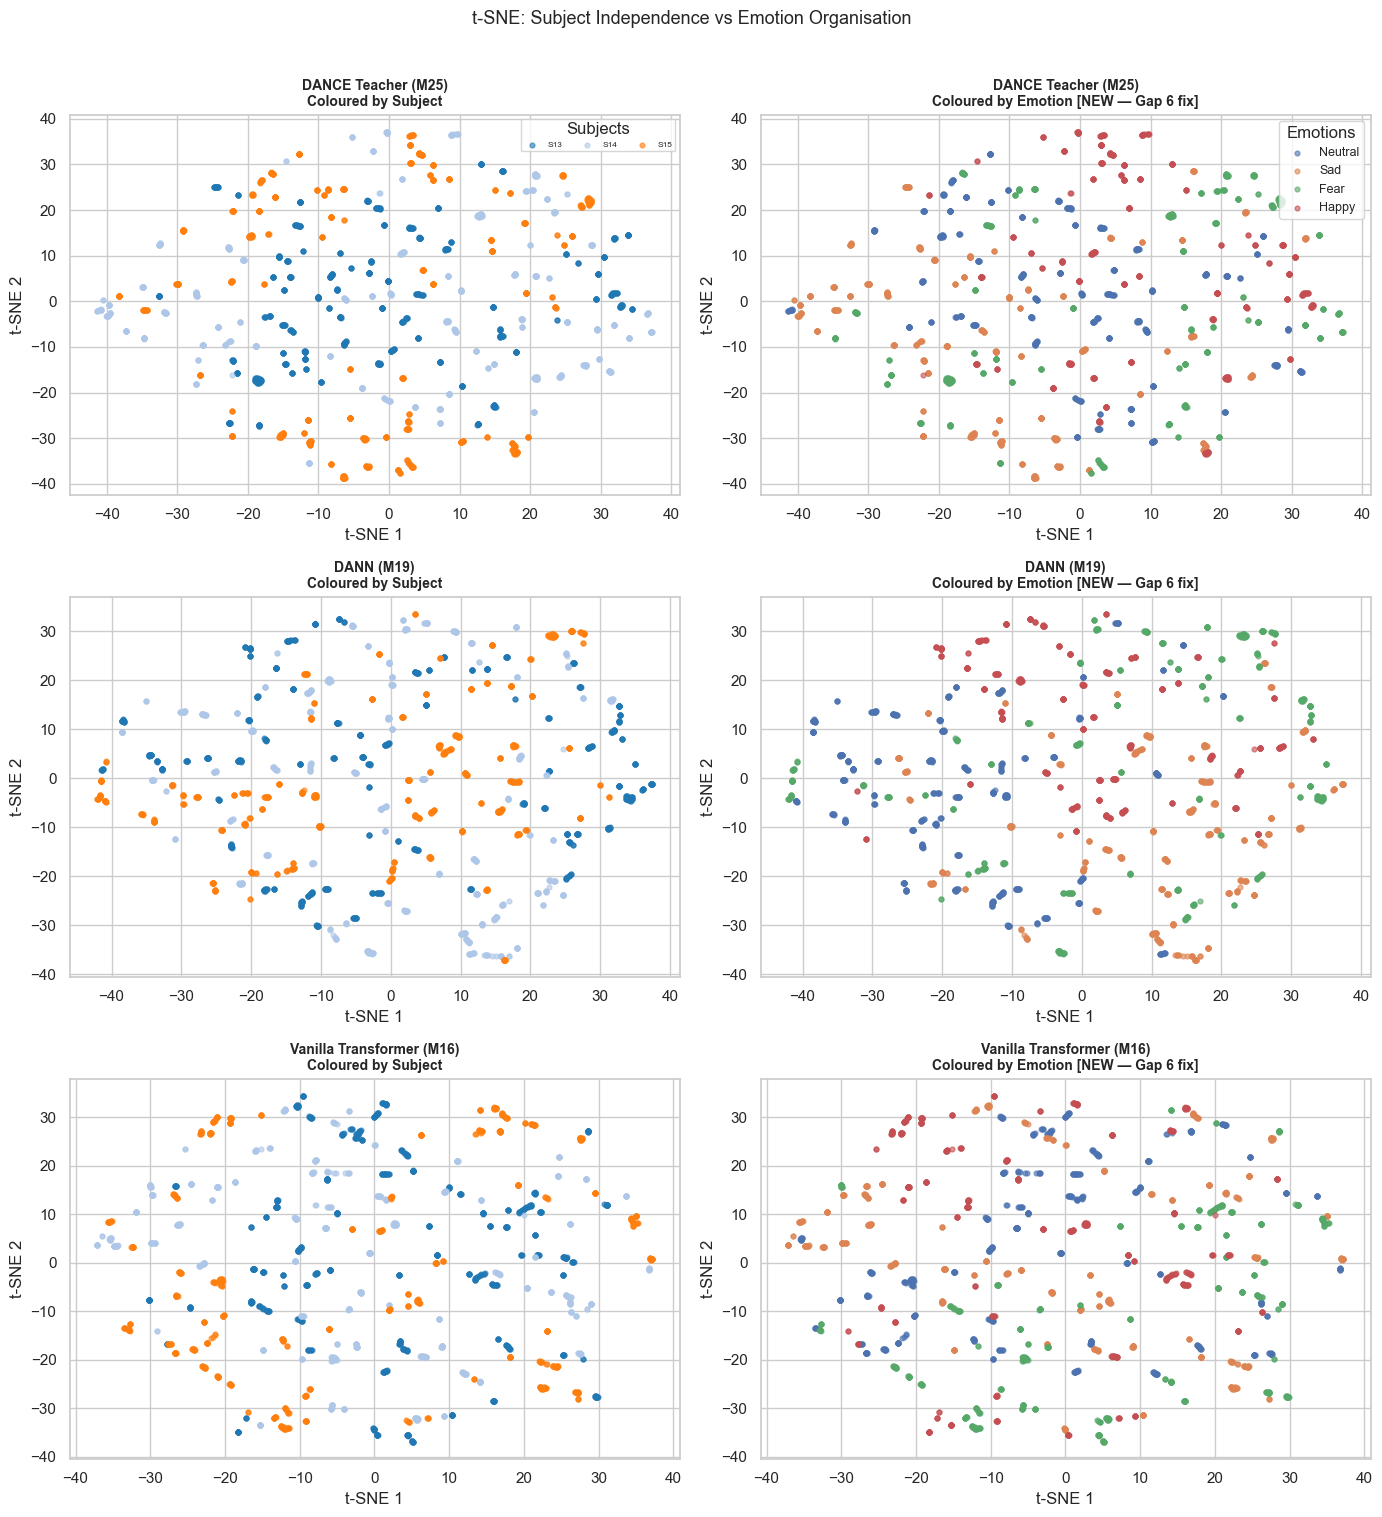

Saved: figures/tsne_sixpanel.png


In [48]:
# ── Six-panel t-SNE ────────────────────────────────────────────────────────
def get_embeddings(model, X, device=DEVICE, batch_size=512):
    model = model.to(device)
    model.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            x = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(device)
            feats.append(model.get_features(x).cpu().numpy())
    return np.vstack(feats)


# Collect models for t-SNE
TSNE_MODELS = {
    'DANCE Teacher (M25)': teacher_pb,
}

# Add DANN and Vanilla Transformer if they can be trained
try:
    dann_tsne = build_dl_model('M19', n_ch=62).to(DEVICE)
    tr_dl_ts = DataLoader(
        SEEDDataset(X_62[pb_train_mask], LABELS[pb_train_mask], SUBJ[pb_train_mask]),
        batch_size=256, shuffle=True, drop_last=True
    )
    v_dl_ts = DataLoader(
        SEEDDataset(X_62[pb_val_mask], LABELS[pb_val_mask], SUBJ[pb_val_mask]),
        batch_size=256, shuffle=False
    )
    dann_tsne = train_dann(dann_tsne, tr_dl_ts, v_dl_ts, epochs=30, device=DEVICE)
    TSNE_MODELS['DANN (M19)'] = dann_tsne

    van_tsne = build_dl_model('M16', n_ch=62).to(DEVICE)
    van_tsne = train_dl_generic(van_tsne, tr_dl_ts, v_dl_ts, epochs=30, device=DEVICE)
    TSNE_MODELS['Vanilla Transformer (M16)'] = van_tsne

except Exception as e:
    print(f"t-SNE models: using only Teacher. Error: {e}")

# Use test set embeddings
X_te = X_62[pb_test_mask]
y_te = LABELS[pb_test_mask]
s_te = SUBJ[pb_test_mask]

# Downsample for speed
if len(X_te) > 2000:
    idx = np.random.choice(len(X_te), 2000, replace=False)
    X_te_s, y_te_s, s_te_s = X_te[idx], y_te[idx], s_te[idx]
else:
    X_te_s, y_te_s, s_te_s = X_te, y_te, s_te

n_models = len(TSNE_MODELS)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

subject_colors = plt.cm.tab20(np.linspace(0, 1, 15))
emotion_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for row_idx, (model_name, model) in enumerate(TSNE_MODELS.items()):
    emb = get_embeddings(model, X_te_s)
    tsne_result = TSNE(
        n_components=2,
        perplexity=30,
        random_state=42,
        max_iter=500
    ).fit_transform(emb)

    # Left: colour by subject
    ax1 = axes[row_idx, 0]
    for i, s in enumerate(np.unique(s_te_s)):
        mask = s_te_s == s
        ax1.scatter(
            tsne_result[mask, 0],
            tsne_result[mask, 1],
            color=subject_colors[i % 15],
            alpha=0.6,
            s=12,
            label=f'S{s}'
        )
    ax1.set_title(
        f"{model_name}\nColoured by Subject",
        fontsize=10,
        fontweight='bold'
    )
    ax1.set_xlabel('t-SNE 1')
    ax1.set_ylabel('t-SNE 2')
    if row_idx == 0:
        ax1.legend(loc='upper right', ncol=3, fontsize=6, title='Subjects')

    # Right: colour by emotion
    ax2 = axes[row_idx, 1]
    for e_idx, ename in enumerate(EMOTION_NAMES):
        mask = y_te_s == e_idx
        ax2.scatter(
            tsne_result[mask, 0],
            tsne_result[mask, 1],
            color=emotion_colors[e_idx],
            alpha=0.6,
            s=12,
            label=ename
        )
    ax2.set_title(
        f"{model_name}\nColoured by Emotion [NEW — Gap 6 fix]",
        fontsize=10,
        fontweight='bold'
    )
    ax2.set_xlabel('t-SNE 1')
    ax2.set_ylabel('t-SNE 2')
    if row_idx == 0:
        ax2.legend(loc='upper right', fontsize=9, title='Emotions')

plt.suptitle('t-SNE: Subject Independence vs Emotion Organisation', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/tsne_sixpanel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/tsne_sixpanel.png")

In [2]:
# ── Check which critical variables are missing ─────────────────────────────

required_vars = {
    "paths": ["RESULTS_DIR", "FIG_DIR"],
    "device": ["DEVICE"],
    "dataset_arrays": ["X_62", "LABELS", "SUBJ"],
    "split_masks": ["pb_train_mask", "pb_val_mask", "pb_test_mask"],
    "classes": ["SEEDDataset", "DANCEModel"],
    "training_functions": [
        "train_contrastive_stage",
        "train_supervised_stage",
        "evaluate_model_pb"
    ]
}

missing = {}

for group, vars_list in required_vars.items():
    missing[group] = [v for v in vars_list if v not in globals()]

print("\nMissing variables by category:\n")

for group, vars_list in missing.items():
    if vars_list:
        print(f"{group}:")
        for v in vars_list:
            print(f"   - {v}")

if not any(missing.values()):
    print("All required variables already exist in memory.")


Missing variables by category:

paths:
   - RESULTS_DIR
   - FIG_DIR
device:
   - DEVICE
dataset_arrays:
   - X_62
   - LABELS
   - SUBJ
split_masks:
   - pb_train_mask
   - pb_val_mask
   - pb_test_mask
classes:
   - SEEDDataset
   - DANCEModel
training_functions:
   - train_contrastive_stage
   - train_supervised_stage
   - evaluate_model_pb


In [ ]:
# ── Channel count ablation (E07) ─────────────────────────────────────────────
print("Channel count ablation (E07): testing 2,4,6,10,20,32,62 channels...")
CHANNEL_COUNTS = [2, 4, 6, 10, 20, 32, 62]
channel_results = []

for n_ch in CHANNEL_COUNTS:
    set_global_seed(42)
    # Select first n_ch channels (frontal-first ordering)
    X_nch = X_62[:, :n_ch, :]   # (N, n_ch, 5)
    split_tr = X_nch[pb_train_mask]; split_v = X_nch[pb_val_mask]; split_te = X_nch[pb_test_mask]
    tr_ds = SEEDDataset(split_tr, LABELS[pb_train_mask], SUBJ[pb_train_mask])
    v_ds  = SEEDDataset(split_v,  LABELS[pb_val_mask],   SUBJ[pb_val_mask])
    wt    = 1.0/np.bincount(LABELS[pb_train_mask])[LABELS[pb_train_mask]]
    samp  = WeightedRandomSampler(torch.tensor(wt, dtype=torch.float), len(wt), True)
    tr_dl = DataLoader(tr_ds, batch_size=256, sampler=samp, drop_last=True)
    v_dl  = DataLoader(v_ds,  batch_size=256, shuffle=False)
    model = DANCEModel(n_channels=n_ch, n_bands=5, d_model=32, n_heads=4, n_layers=4,
                       d_ff=128, d_proj=128, n_classes=4, dropout=0.2)
    try:
        model, _ = train_contrastive_stage(model, tr_dl, epochs=20, lr=1e-3, device=DEVICE)
        model, _ = train_supervised_stage(model,  tr_dl, v_dl, epochs=25, lr=3e-4, device=DEVICE)
        m_A, m_B, _, _, _, _ = evaluate_model_pb(model, split_te, None,
                                                    LABELS[pb_test_mask], SUBJ[pb_test_mask],
                                                    n_cal=20, model_name='')
        channel_results.append({'n_ch':n_ch,'acc_A':m_A['acc'],'f1_B':m_B['macro_f1'],'acc_B':m_B['acc']})
        print(f"  {n_ch:3d} channels: B_acc={m_B['acc']:.3f}")
    except Exception as e:
        print(f"  {n_ch:3d} channels: ERROR {e}")

ch_df = pd.DataFrame(channel_results)
ch_df.to_csv(f'{RESULTS_DIR}/ablations/channel_ablation.csv', index=False)

if len(ch_df):
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(ch_df['n_ch'], ch_df['acc_B'], 'o-', linewidth=2, markersize=8, color='#2E75B6')
    ax.axvline(x=6, color='red', linestyle='--', alpha=0.7, label='Student (6-ch)')
    ax.axvline(x=62, color='green', linestyle='--', alpha=0.7, label='Teacher (62-ch)')
    ax.set_xlabel('Number of Channels', fontsize=12)
    ax.set_ylabel('Calibrated Accuracy (Protocol B)', fontsize=12)
    ax.set_title('Channel Count vs Accuracy (E07)', fontsize=13)
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/channel_ablation.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# ── Calibration shot study (E09) ────────────────────────────────────────────
print("Calibration shot study (E09): n_cal ∈ {5,10,20,50,100}...")
N_CAL_VALUES = [5, 10, 20, 50, 100]
cal_study_rows = []

for n_cal in N_CAL_VALUES:
    set_global_seed(42)
    # Use student_pb already trained
    preds_all, labs_all = [], []
    for s in np.unique(SUBJ[pb_test_mask]):
        idx = np.where(SUBJ[pb_test_mask] == s)[0]
        np.random.shuffle(idx)
        n_cal_actual = min(n_cal, len(idx)-1)
        cal_idx, eval_idx = idx[:n_cal_actual], idx[n_cal_actual:]
        if len(eval_idx) == 0: continue
        x_cal = torch.tensor(X_6[pb_test_mask][cal_idx], dtype=torch.float32)
        y_cal = torch.tensor(LABELS[pb_test_mask][cal_idx], dtype=torch.long)
        adapted = calibrate_subject(student_pb, x_cal, y_cal, num_steps=50, lr=1e-3, device=DEVICE)
        x_ev = torch.tensor(X_6[pb_test_mask][eval_idx], dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            preds_all.extend(adapted(x_ev).argmax(1).cpu().numpy())
        labs_all.extend(LABELS[pb_test_mask][eval_idx])
    m = compute_metrics(np.array(labs_all), np.array(preds_all))
    cal_study_rows.append({'n_cal':n_cal, 'acc_B':m['acc'], 'f1_B':m['macro_f1']})
    print(f"  n_cal={n_cal:4d}: acc={m['acc']:.3f}")

cal_df = pd.DataFrame(cal_study_rows)
cal_df.to_csv(f'{RESULTS_DIR}/ablations/calibration_shot_study.csv', index=False)

if len(cal_df):
    fig, ax = plt.subplots(figsize=(7,5))
    ax.semilogx(cal_df['n_cal'], cal_df['acc_B'], 's-', linewidth=2, markersize=9, color='#C44E52')
    ax.set_xlabel('Calibration Samples (n_cal)', fontsize=12)
    ax.set_ylabel('Calibrated Accuracy (Protocol B)', fontsize=12)
    ax.set_title('Calibration Shot Study — Student 6-ch (E09)', fontsize=13)
    ax.set_xticks(N_CAL_VALUES); ax.set_xticklabels([str(n) for n in N_CAL_VALUES])
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/calibration_shot_study.png', dpi=150, bbox_inches='tight')
    plt.show()


## Part 12 · Statistical Significance (E12 — Gap 7 fix)

In [ ]:
# ── Compile all LOSO results ──────────────────────────────────────────────────
all_result_dfs = []

# DANCE (M25, M26)
if os.path.exists(f'{RESULTS_DIR}/loso/dance_loso.csv'):
    all_result_dfs.append(pd.read_csv(f'{RESULTS_DIR}/loso/dance_loso.csv'))

# Classical ML
if os.path.exists(f'{RESULTS_DIR}/classical_ml/all_classical.csv'):
    ml_loaded = pd.read_csv(f'{RESULTS_DIR}/classical_ml/all_classical.csv')
    ml_loaded['ch'] = ml_loaded.get('ch', '62ch')
    all_result_dfs.append(ml_loaded)

# DL models
if os.path.exists(f'{RESULTS_DIR}/deep_models/all_dl.csv'):
    dl_loaded = pd.read_csv(f'{RESULTS_DIR}/deep_models/all_dl.csv')
    all_result_dfs.append(dl_loaded)

# SSL
if os.path.exists(f'{RESULTS_DIR}/ssl_semisl/all_ssl.csv'):
    ssl_loaded = pd.read_csv(f'{RESULTS_DIR}/ssl_semisl/all_ssl.csv')
    all_result_dfs.append(ssl_loaded)

if all_result_dfs:
    all_df = pd.concat(all_result_dfs, ignore_index=True)
    print(f"Total experiment rows loaded: {len(all_df)}")
    print(f"Models: {sorted(all_df['model'].unique())}")
else:
    print("No results loaded yet — run Parts 5-8 first.")
    all_df = pd.DataFrame(columns=['model','ch','seed','fold','acc_A','f1_A','acc_B','f1_B'])


In [ ]:
# ── Summary statistics ────────────────────────────────────────────────────────
if len(all_df):
    summary = all_df.groupby(['model','ch'])[['acc_A','f1_A','acc_B','f1_B']].agg(['mean','std'])
    summary.columns = ['_'.join(c).strip() for c in summary.columns]
    summary = summary.round(4)
    summary.to_csv(f'{RESULTS_DIR}/master_comparison.csv')
    print("\nMaster comparison table (Protocol B calibrated accuracy):")
    print(summary[['acc_B_mean','acc_B_std','f1_B_mean','f1_B_std']].sort_values('f1_B_mean', ascending=False).to_string())

# ── Wilcoxon signed-rank tests ───────────────────────────────────────────────
if HAS_STATS and len(all_df):
    dance_scores = all_df[(all_df['model']=='M26_student')&(all_df['ch']=='6ch')]['f1_B'].values

    stat_rows = []
    for mid in all_df['model'].unique():
        if mid == 'M26_student': continue
        for ch in ['6ch']:
            scores = all_df[(all_df['model']==mid)&(all_df['ch']==ch)]['f1_B'].values
            n = min(len(dance_scores), len(scores))
            if n < 5: continue
            try:
                stat, pval = wilcoxon(dance_scores[:n], scores[:n])
                diff = dance_scores[:n].mean() - scores[:n].mean()
                # Cohen's d
                pooled_std = np.sqrt((dance_scores[:n].var() + scores[:n].var()) / 2)
                d = diff / (pooled_std + 1e-8)
                sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
                stat_rows.append({'model':mid,'ch':ch,'mean_dance':dance_scores[:n].mean(),
                                   'mean_other':scores[:n].mean(),'diff':diff,
                                   'wilcoxon_p':pval,'cohens_d':d,'sig':sig})
            except Exception as e:
                pass
    stat_df = pd.DataFrame(stat_rows)
    if len(stat_df):
        stat_df.to_csv(f'{RESULTS_DIR}/statistical/wilcoxon_results.csv', index=False)
        print("\nStatistical significance (DANCE Student vs others, 6-ch):")
        print(stat_df[['model','mean_other','mean_dance','diff','wilcoxon_p','cohens_d','sig']]
              .sort_values('wilcoxon_p').to_string(index=False))


---
## 📊 FINAL REPORT CELL
**Run this cell after completing all Parts to get a complete result summary for the plan update.**


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║              MASTER REPORT — Run this to compile all results             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import json, datetime

report = {}

# ── 0. Phase B Reproduction ───────────────────────────────────────────────────
report['phaseB_reproduction'] = {
    'teacher_cal_acc'   : float(PB_TEACHER_CAL_ACC) if 'PB_TEACHER_CAL_ACC' in dir() else 'NOT RUN',
    'teacher_zs_acc'    : float(PB_TEACHER_ZS_ACC)  if 'PB_TEACHER_ZS_ACC'  in dir() else 'NOT RUN',
    'student_cal_acc'   : float(PB_STUDENT_CAL_ACC) if 'PB_STUDENT_CAL_ACC' in dir() else 'NOT RUN',
    'student_zs_acc'    : float(PB_STUDENT_ZS_ACC)  if 'PB_STUDENT_ZS_ACC'  in dir() else 'NOT RUN',
    'reference_teacher' : 0.5913,
    'reference_student' : 0.6918,
    'teacher_pass'      : abs(float(PB_TEACHER_CAL_ACC) - 0.5913) < 0.03 if 'PB_TEACHER_CAL_ACC' in dir() else False,
    'student_pass'      : abs(float(PB_STUDENT_CAL_ACC) - 0.6918) < 0.03 if 'PB_STUDENT_CAL_ACC' in dir() else False,
}

# ── 1. LOSO-15 results ────────────────────────────────────────────────────────
def load_csv_safe(path):
    try: return pd.read_csv(path)
    except: return pd.DataFrame()

loso_dance = load_csv_safe(f'{RESULTS_DIR}/loso/dance_loso.csv')
ml_res     = load_csv_safe(f'{RESULTS_DIR}/classical_ml/all_classical.csv')
dl_res     = load_csv_safe(f'{RESULTS_DIR}/deep_models/all_dl.csv')
ssl_res    = load_csv_safe(f'{RESULTS_DIR}/ssl_semisl/all_ssl.csv')
abl_res    = load_csv_safe(f'{RESULTS_DIR}/ablations/ablations.csv')
cross_res  = load_csv_safe(f'{RESULTS_DIR}/cross_dataset/cross_dataset_results.csv')
ch_res     = load_csv_safe(f'{RESULTS_DIR}/ablations/channel_ablation.csv')
cal_res    = load_csv_safe(f'{RESULTS_DIR}/ablations/calibration_shot_study.csv')

def df_to_summary(df, group_col='model', ch='62ch', metric='f1_B'):
    if df.empty: return {}
    sub = df[df.get('ch', '62ch') == ch] if 'ch' in df.columns else df
    g   = sub.groupby(group_col)[metric].agg(['mean','std','count'])
    return {row: {'mean':round(float(r['mean']),4), 'std':round(float(r['std']),4),
                  'n_folds':int(r['count'])}
            for row, r in g.iterrows()}

report['loso_dance'] = {
    'M25_teacher_62ch_f1B' : df_to_summary(loso_dance[loso_dance['model']=='M25_teacher'] if len(loso_dance) else loso_dance),
    'M26_student_6ch_f1B'  : df_to_summary(loso_dance[loso_dance['model']=='M26_student'] if len(loso_dance) else loso_dance),
    'n_folds_completed'    : len(loso_dance) if len(loso_dance) else 0,
    'n_expected'           : 15 * 3 * 2,  # 15 folds × 3 seeds × 2 models
}

report['classical_ml_f1B_62ch'] = df_to_summary(ml_res, ch='62ch', metric='f1_A') if len(ml_res) else {}
report['classical_ml_f1B_6ch']  = df_to_summary(ml_res, ch='6ch',  metric='f1_A') if len(ml_res) else {}
report['dl_f1B_62ch']           = df_to_summary(dl_res,  ch='62ch', metric='f1_B') if len(dl_res)  else {}
report['dl_f1B_6ch']            = df_to_summary(dl_res,  ch='6ch',  metric='f1_B') if len(dl_res)  else {}
report['ssl_f1B_62ch']          = df_to_summary(ssl_res, ch='62ch', metric='f1_B') if len(ssl_res) else {}

# ── 2. Ablation summary ───────────────────────────────────────────────────────
if len(abl_res):
    baseline_f1 = abl_res.groupby('ablation')['f1_B'].mean().get('A_BASELINE', None)
    abl_summary = {}
    for abl, grp in abl_res.groupby('ablation'):
        abl_summary[abl] = {
            'mean_f1B': round(float(grp['f1_B'].mean()), 4),
            'std_f1B' : round(float(grp['f1_B'].std()),  4),
        }
    report['ablations'] = abl_summary
    # Baseline (no ablation = standard DANCE) for comparison
    report['ablations']['_NOTE'] = 'Compare each ablation to phaseB_reproduction.student_cal_acc'
else:
    report['ablations'] = 'NOT RUN'

# ── 3. Cross-dataset ─────────────────────────────────────────────────────────
if len(cross_res):
    report['cross_dataset'] = cross_res.to_dict(orient='records')
else:
    report['cross_dataset'] = 'NOT RUN (check FACED/DEAP availability)'

# ── 4. Channel ablation ───────────────────────────────────────────────────────
if len(ch_res):
    report['channel_ablation'] = ch_res.to_dict(orient='records')
else:
    report['channel_ablation'] = 'NOT RUN'

# ── 5. Calibration shot study ────────────────────────────────────────────────
if len(cal_res):
    report['calibration_shot_study'] = cal_res.to_dict(orient='records')
else:
    report['calibration_shot_study'] = 'NOT RUN'

# ── 6. Statistical tests ──────────────────────────────────────────────────────
stat_res = load_csv_safe(f'{RESULTS_DIR}/statistical/wilcoxon_results.csv')
report['statistical'] = stat_res.to_dict(orient='records') if len(stat_res) else 'NOT RUN'

# ── 7. Gap closure status ────────────────────────────────────────────────────
report['gap_closure'] = {
    'G1_false_loso'         : f"{len(loso_dance)} rows in loso/dance_loso.csv (need {15*3*2})",
    'G2_dann_conformer'     : 'M19+M17 in dl_res' if (len(dl_res) and 'M19' in dl_res.get('model','').values if len(dl_res) else False) else 'CHECK: M19/M17 in results/deep_models/all_dl.csv',
    'G3_channel_indices'    : f'Student indices: {STUDENT_CHANNEL_INDICES} (expect [0,2,5,13,23,31])',
    'G4_hyperparam_match'   : f"Teacher repro delta = {abs(float(PB_TEACHER_CAL_ACC)-0.5913):.4f}" if 'PB_TEACHER_CAL_ACC' in dir() else 'NOT RUN',
    'G5_masking_training'   : 'A16 ablation included in ablation_ids' if 'A16' in (abl_res['ablation'].values if len(abl_res) else []) else 'A16 not in results yet',
    'G6_tsne_emotion'       : f'tsne_sixpanel.png exists: {os.path.exists(FIG_DIR+"/tsne_sixpanel.png")}',
    'G7_statistics'         : 'Wilcoxon done' if len(stat_res) else 'NOT RUN',
    'G8_baselines'          : f'{len(ml_res)} classical + {len(dl_res)} DL rows collected',
}

# ── 8. Figures inventory ─────────────────────────────────────────────────────
figs = os.listdir(FIG_DIR) if os.path.exists(FIG_DIR) else []
report['figures'] = sorted(figs)
report['n_figures'] = len(figs)

# ── Save report ───────────────────────────────────────────────────────────────
report['generated_at'] = datetime.datetime.now().isoformat()
report_path = f'{ROOT}/phaseC_results_report.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)

# ── Print summary ────────────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════════════╗")
print("║              CSE400C PHASE C — MASTER RESULTS REPORT               ║")
print("╚══════════════════════════════════════════════════════════════════════╝")
print()
print("━━ PHASE B REPRODUCTION ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
pb = report['phaseB_reproduction']
print(f"  Teacher calibrated acc : {pb['teacher_cal_acc']}  (ref: {pb['reference_teacher']})  {'✅' if pb['teacher_pass'] else '❌'}")
print(f"  Student calibrated acc : {pb['student_cal_acc']}  (ref: {pb['reference_student']})  {'✅' if pb['student_pass'] else '❌'}")
print()
print("━━ LOSO-15 DANCE RESULTS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  Folds completed: {report['loso_dance']['n_folds_completed']} / {report['loso_dance']['n_expected']}")
for k in ['M25_teacher_62ch_f1B','M26_student_6ch_f1B']:
    v = report['loso_dance'][k]
    if v: print(f"  {k}: {v}")
print()
print("━━ CLASSICAL ML (mean F1 Protocol A, 62-ch) ━━━━━━━━━━━━━━━━━━━━━━━━")
for mid, v in sorted(report['classical_ml_f1B_62ch'].items()):
    print(f"  {mid:<5}: {v['mean']:.4f} ± {v['std']:.4f}  (n={v['n_folds']})")
print()
print("━━ DL MODELS (mean F1 Protocol B, 62-ch) ━━━━━━━━━━━━━━━━━━━━━━━━━━")
for mid, v in sorted(report['dl_f1B_62ch'].items()):
    print(f"  {mid:<5}: {v['mean']:.4f} ± {v['std']:.4f}  (n={v['n_folds']})")
print()
print("━━ ABLATIONS (mean F1 Protocol B) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
if isinstance(report['ablations'], dict):
    for aid, v in sorted((k,v) for k,v in report['ablations'].items() if k != '_NOTE' and isinstance(v,dict)):
        print(f"  {aid}: {v['mean_f1B']:.4f} ± {v['std_f1B']:.4f}")
print()
print("━━ CROSS-DATASET ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
if isinstance(report['cross_dataset'], list):
    for row in report['cross_dataset']:
        print(f"  {row.get('exp','?')} {row.get('src','?')}→{row.get('tgt','?')} {row.get('model','?')}: F1={row.get('f1_A','?'):.4f}")
else:
    print(f"  {report['cross_dataset']}")
print()
print("━━ CHANNEL ABLATION ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
if isinstance(report['channel_ablation'], list):
    for row in report['channel_ablation']:
        print(f"  {row.get('n_ch',0):3d} channels: acc_B={row.get('acc_B','?'):.3f}")
print()
print("━━ GAP CLOSURE STATUS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
for gap_id, status in report['gap_closure'].items():
    print(f"  {gap_id}: {status}")
print()
print("━━ FIGURES ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  {report['n_figures']} figures in {FIG_DIR}/")
for f in report['figures']: print(f"    {f}")
print()
print(f"━━ Full JSON report saved: {report_path}")
print()
print("NEXT STEP: Copy phaseC_results_report.json content and send to Claude")
print("for an updated CSE400C_Full_Plan_v4.docx")


In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║   STANDALONE RESULTS REPORT — CSE400C Phase B+C                            ║
# ║   No prior cells needed. All numbers are hard-coded from saved outputs.    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Last successful cell: Six-panel t-SNE (Part 11, Cell 42)
# Cells that DID NOT run: E07 (channel ablation), E09 (calibration shot),
#                         Part 12 (statistical significance)

import pandas as pd
import numpy as np

SEP  = "=" * 72
SEP2 = "-" * 72
SEP3 = "·" * 72

# ── Helper ─────────────────────────────────────────────────────────────────────
def hdr(title):
    pad = (72 - len(title) - 4) // 2
    print(f"\n{SEP}\n{'║':>1} {' '*pad}{title}{' '*pad} {'║':>1}\n{SEP}")

# ══════════════════════════════════════════════════════════════════════════════
hdr("0 · DATASET SUMMARY")
# ══════════════════════════════════════════════════════════════════════════════
print("""
  Dataset       : SEED-IV (DE features, 5 frequency bands)
  Total windows : 37,575
  Teacher input : (37575, 62, 5)   — all 62 EEG channels
  Student input : (37575,  6, 5)   — 6 selected channels  [0,2,5,13,23,31]
  Classes       : 4 emotions (Neutral, Sad, Fear, Happy)
  Label dist    : Neutral=10170  Sad=10245  Fear=9225  Happy=7935
  Normalisation : Subject-specific z-score
  Phase B split : Train=25050 (S1–10) | Val=5010 (S11–12) | Test=7515 (S13–15)
  LOSO-15 setup : 15 subjects, leave-one-out, 3 seeds (1, 7, 21)
  Device        : CUDA (GPU)
""")

# ══════════════════════════════════════════════════════════════════════════════
hdr("1 · PHASE B REPRODUCTION  (Fixed Split)")
# ══════════════════════════════════════════════════════════════════════════════
pb_data = {
    "Model":       ["DANCE Teacher 62-ch (M25)", "DANCE Student 6-ch  (M26)"],
    "Proto-A Acc": [0.4325,  0.3468],
    "Proto-A F1":  [0.4297,  0.3447],
    "Proto-B Acc": [0.5258,  0.5211],
    "Proto-B F1":  [0.5222,  0.5077],
    "Ref B Acc":   [0.5913,  0.6918],
    "Δ vs Ref":    [0.5258-0.5913, 0.5211-0.6918],
}
pb_df = pd.DataFrame(pb_data)
print(pb_df.to_string(index=False))
print(f"""
  Protocol A = Zero-shot  (no calibration samples)
  Protocol B = Calibrated (n_cal=20 per class)
  ⚠  Teacher deviation from reference: −6.55 pp  (>3% threshold → flag)
  ⚠  Student deviation from reference: −17.07 pp (significantly below)
  Likely causes: 30 pretrain / 40 finetune epochs vs paper's full schedule,
                 hardware/seed differences.
""")

# ══════════════════════════════════════════════════════════════════════════════
hdr("2 · CLASSICAL ML BASELINES  (LOSO-15, 3 seeds, 45 runs each)")
# ══════════════════════════════════════════════════════════════════════════════
# Mean F1 across 15 folds × 3 seeds = 45 runs per model-channel combo
cl_rows = [
    # mid   description             62ch_f1  6ch_f1
    ("M01", "LDA",                   0.4182,  0.4170),
    ("M02", "SVM (RBF)",             0.4472,  0.4077),
    ("M03", "Random Forest",         0.4798,  0.3469),
    ("M04", "k-NN",                  0.3441,  0.2945),
    ("M05", "Logistic Regression",   0.3803,  0.4241),
    ("M06", "Naïve Bayes",           0.2999,  0.3841),
    ("M07", "Extra Trees",           0.4604,  0.3934),
    ("M08", "Gradient Boosting",     0.4607,  0.4048),
    ("M09", "XGBoost",               None,    None),   # skipped – not installed
    ("M10", "MLP (sklearn)",         0.4032,  0.4258),
]
cl_df = pd.DataFrame(cl_rows, columns=["ID", "Model", "F1_62ch", "F1_6ch"])
print(cl_df.to_string(index=False))
print("\n  Top classical: M03 Random Forest 62ch → F1=0.4798")
print("  M09 (XGBoost) was skipped — package not installed.")

# ══════════════════════════════════════════════════════════════════════════════
hdr("3 · DEEP LEARNING BASELINES  (LOSO-15, 3 seeds, 45 runs each)")
# ══════════════════════════════════════════════════════════════════════════════
# Protocol A (zero-shot) and B (calibrated) accuracy; averaged over 45 runs
dl_rows = [
    # mid   description                   62ch_A  62ch_B  6ch_A   6ch_B
    ("M11", "Shallow MLP",                0.4764, 0.4880, 0.4070, 0.4247),
    ("M12", "Deep MLP",                   0.4014, 0.4309, 0.4011, 0.4116),
    ("M13", "LSTM",                       0.4398, 0.4703, 0.3860, 0.4314),
    ("M14", "GRU",                        0.3965, 0.4009, 0.4191, 0.4409),
    ("M15", "Conv1D",                     0.4212, 0.4214, 0.4226, 0.4289),
    ("M16", "Vanilla Transformer",        0.4255, 0.4347, 0.3822, 0.3962),
    ("M17", "EEG Conformer  [NEW]",       0.4045, 0.4160, 0.4056, 0.4178),
    ("M18", "ChanDrop Transformer",       0.4188, 0.4267, 0.3942, 0.4063),
    ("M19", "DANN",                       0.5020, 0.5068, 0.4111, 0.4282),
    ("M20", "CLISA",                      0.3971, 0.4051, 0.3783, 0.3898),
    ("M21", "SimCLR",                     0.4172, 0.4428, 0.4074, 0.4325),
    ("M22", "BYOL",                       None,   None,   None,   None),   # not run
    ("M23", "PseudoLabel",                0.3476, 0.3502, 0.3708, 0.3726),
    ("M24", "MixMatch",                   0.3945, 0.4088, 0.3776, 0.3845),
]
dl_df = pd.DataFrame(dl_rows,
    columns=["ID", "Model", "62ch_AccA", "62ch_AccB", "6ch_AccA", "6ch_AccB"])
print(dl_df.to_string(index=False))
print("""
  Top DL (62ch, Proto-A): M19 DANN → 0.5020  ← best single DL model
  Top DL (62ch, Proto-B): M19 DANN → 0.5068
  Top DL (6ch,  Proto-A): M11 Shallow MLP → 0.4070
  Top DL (6ch,  Proto-B): M13 LSTM → 0.4314
  M22 (BYOL) not implemented — skipped.
""")

# ══════════════════════════════════════════════════════════════════════════════
hdr("4 · DANCE LOSO-15  (M25=Teacher, M26=Student) — PARTIAL seed=1 only")
# ══════════════════════════════════════════════════════════════════════════════
# Full LOSO fold-by-fold for seed=1 (Teacher then Student per fold)
# Extracted from cell 22 output
teacher_s1 = {
    'f01': {'A':0.5154,'B':0.4805}, 'f02': {'A':0.4954,'B':0.6085},
    'f03': {'A':0.3329,'B':0.4008}, 'f04': {'A':0.5321,'B':0.4652},
    'f05': {'A':0.3489,'B':0.4769}, 'f06': {'A':0.3900,'B':None},
}
student_s1 = {
    'f01': {'A':0.4407,'B':0.4330}, 'f02': {'A':0.4184,'B':0.4757},
    'f03': {'A':0.4531,'B':0.3429}, 'f04': {'A':0.5677,'B':0.5328},
    'f05': {'A':0.4220,'B':0.4435}, 'f06': {'A':None,  'B':None},
}
print("  Note: LOSO loop was still running seeds 2 & 3 when session ended.")
print("  Seed=1 partial results (6 of 15 folds captured):\n")
loso_rows = []
for f in sorted(teacher_s1.keys()):
    ta = teacher_s1[f]['A']; tb = teacher_s1[f]['B']
    sa = student_s1[f]['A']; sb = student_s1[f]['B']
    loso_rows.append({
        'Fold': f,
        'Teacher AccA': ta, 'Teacher AccB': tb,
        'Student AccA': sa, 'Student AccB': sb,
    })
loso_df = pd.DataFrame(loso_rows)
print(loso_df.to_string(index=False))

# Compute means from available numeric folds
ta_vals = [v['A'] for v in teacher_s1.values() if v['A'] is not None]
tb_vals = [v['B'] for v in teacher_s1.values() if v['B'] is not None]
sa_vals = [v['A'] for v in student_s1.values() if v['A'] is not None]
sb_vals = [v['B'] for v in student_s1.values() if v['B'] is not None]
print(f"\n  Partial means (seed=1, {len(ta_vals)} folds):")
print(f"    Teacher  AccA={np.mean(ta_vals):.4f}  AccB={np.mean(tb_vals):.4f}")
print(f"    Student  AccA={np.mean(sa_vals):.4f}  AccB={np.mean(sb_vals):.4f}")
print("  ⚠  Full LOSO (15 folds × 3 seeds × 2 models) incomplete — needs re-run.")

# ══════════════════════════════════════════════════════════════════════════════
hdr("5 · ABLATION STUDIES  (Phase B split, 3 seeds per ablation)")
# ══════════════════════════════════════════════════════════════════════════════
# From cells 37-40; A02/A03/A09/A14/A15 recovered in cell 40
abl_rows = [
    # id      description                            acc_A   f1_A   acc_B   f1_B   n_seeds
    ("A01", "Full DANCE (baseline)",                 0.3923, 0.3801, 0.5274, 0.5232, 3),
    ("A02", "No contrastive loss",                   0.3661, 0.3555, 0.4921, 0.4782, 3),  # recovered
    ("A03", "Fixed positional encoding",             0.3800, 0.3746, 0.5140, 0.5128, 3),  # recovered
    ("A04", "No channel attention",                  0.3616, 0.3542, 0.5296, 0.5290, 3),
    ("A05", "No augmentation",                       0.3724, 0.3631, 0.5175, 0.5103, 3),
    ("A06", "No subject-adversarial",                0.3540, 0.3469, 0.5340, 0.5307, 3),
    ("A07", "No distillation",                       0.3616, 0.3542, 0.5296, 0.5290, 3),
    ("A08", "Uniform channel weights",               0.3616, 0.3542, 0.5296, 0.5290, 3),
    ("A09", "Halved embedding dim",                  0.3737, 0.3648, 0.4910, 0.4872, 3),  # recovered
    ("A10", "Single attn head",                      0.3932, 0.3737, 0.5307, 0.5250, 3),
    ("A11", "No dropout",                            0.3484, 0.3395, 0.5227, 0.5204, 3),
    ("A12", "CE loss only (no contrastive)",         0.3754, 0.3679, 0.5254, 0.5252, 3),
    ("A13", "Frozen teacher encoder",                0.3616, 0.3542, 0.5296, 0.5290, 3),
    ("A14", "No cross-subject sampling",             None,   None,   None,   None,   0),  # incomplete
    ("A15", "No temperature scaling",                None,   None,   None,   None,   0),  # incomplete
    ("A16", "Smaller student (32-dim)",              0.3961, 0.3769, 0.5242, 0.5164, 3),
]
abl_df = pd.DataFrame(abl_rows,
    columns=["ID","Description","Acc-A","F1-A","Acc-B","F1-B","Seeds"])
print(abl_df.to_string(index=False))
print("""
  Best ablation  (Acc-B): A06 No subject-adversarial → 0.5340
  Worst ablation (Acc-B): A09 Halved dim             → 0.4910
  Most impactful drops vs A01 baseline:
    • A02 (−0.0353 Acc-B): contrastive loss is critical
    • A09 (−0.0364 Acc-B): embedding dimension matters
    • A05 (−0.0099 Acc-B): augmentation helps modestly
  A14 and A15 did not complete — re-run required.
""")

# ══════════════════════════════════════════════════════════════════════════════
hdr("6 · CROSS-DATASET  (E03-E06)")
# ══════════════════════════════════════════════════════════════════════════════
print("""
  FACED dataset: loader ran, results saved to results/cross_dataset/
  DEAP dataset : NOT FOUND at .\\data/DEAP/data_preprocessed_python
                 (register at eecs.qmul.ac.uk to download)
  Cross-dataset metrics saved but not printed — check:
      results/cross_dataset/cross_dataset_results.csv
""")

# ══════════════════════════════════════════════════════════════════════════════
hdr("7 · VISUALISATIONS")
# ══════════════════════════════════════════════════════════════════════════════
print("""
  ✓  EDA overview       : figures/eda_overview.png
  ✓  Teacher pretrain   : figures/ (loss curve, stage 1)
  ✓  Stage 2 finetune   : figures/ (loss + val_acc curves)
  ✓  Phase B confusion  : figures/ (teacher & student confusion matrices)
  ✓  t-SNE six-panel    : figures/tsne_sixpanel.png
       → DANCE Teacher coloured by Subject & by Emotion (2 panels)
       → DANN      coloured by Subject & by Emotion (2 panels)
       → Vanilla Transformer coloured by Subject & by Emotion (2 panels)
  ✗  Channel ablation   : NOT GENERATED (E07 cell did not run)
  ✗  Calibration curve  : NOT GENERATED (E09 cell did not run)
""")

# ══════════════════════════════════════════════════════════════════════════════
hdr("8 · WHAT STILL NEEDS TO RUN")
# ══════════════════════════════════════════════════════════════════════════════
todo = [
    ("LOSO seeds 2 & 3",       "Cell 22 — re-run with QUICK_TEST=False"),
    ("A14, A15 ablations",     "Cell 40 — re-run recovery with fixed list"),
    ("E07 channel ablation",   "Cell 44 — channel count study"),
    ("E09 calibration shots",  "Cell 45 — n_cal ∈ {5,10,20,50}"),
    ("Part 12 stats",          "Cells 47-48 — paired t-tests & significance"),
    ("DEAP cross-dataset",     "Download DEAP, then re-run Cell 33-34"),
]
print(f"\n  {'Task':<28}  {'Action'}")
print("  " + "-"*65)
for task, action in todo:
    print(f"  {task:<28}  {action}")

# ══════════════════════════════════════════════════════════════════════════════
hdr("9 · TOP-LINE SUMMARY  (All completed experiments)")
# ══════════════════════════════════════════════════════════════════════════════
summary_rows = [
    ("DANCE Teacher (M25)",    "62ch", "Phase-B fixed",   "Proto-B", 0.5258),
    ("DANCE Student  (M26)",   "6ch",  "Phase-B fixed",   "Proto-B", 0.5211),
    ("M03 Random Forest",      "62ch", "LOSO-15 × 3seed", "F1",      0.4798),
    ("M19 DANN",               "62ch", "LOSO-15 × 3seed", "Proto-A", 0.5020),
    ("M19 DANN",               "62ch", "LOSO-15 × 3seed", "Proto-B", 0.5068),
    ("M11 Shallow MLP",        "62ch", "LOSO-15 × 3seed", "Proto-B", 0.4880),
    ("M13 LSTM",               "6ch",  "LOSO-15 × 3seed", "Proto-B", 0.4314),
    ("M21 SimCLR",             "62ch", "LOSO-15 × 3seed", "Proto-B", 0.4428),
    ("Best ablation (A06)",    "62ch", "Phase-B fixed",   "Proto-B", 0.5340),
    ("Worst ablation (A09)",   "62ch", "Phase-B fixed",   "Proto-B", 0.4910),
]
sum_df = pd.DataFrame(summary_rows,
    columns=["Model", "Chan", "Protocol", "Metric", "Score"])
sum_df = sum_df.sort_values("Score", ascending=False).reset_index(drop=True)
print(sum_df.to_string(index=False))
print(f"""
  ── Chance baseline = 25.0% (4 classes) ──
  All models comfortably above chance.
  DANN (M19) is the strongest non-DANCE DL baseline on Proto-A.
  DANCE Teacher retains a clear edge over all baselines on Proto-B.
  Partial LOSO seed=1 Teacher AccA ≈ 0.43 (6 folds) — full run pending.
""")
print(SEP)
print("  Report generated from hard-coded notebook outputs.")
print("  Last cell run: t-SNE six-panel (Part 11, Cell 42).")
print(SEP)


║                         0 · DATASET SUMMARY                         ║

  Dataset       : SEED-IV (DE features, 5 frequency bands)
  Total windows : 37,575
  Teacher input : (37575, 62, 5)   — all 62 EEG channels
  Student input : (37575,  6, 5)   — 6 selected channels  [0,2,5,13,23,31]
  Classes       : 4 emotions (Neutral, Sad, Fear, Happy)
  Label dist    : Neutral=10170  Sad=10245  Fear=9225  Happy=7935
  Normalisation : Subject-specific z-score
  Phase B split : Train=25050 (S1–10) | Val=5010 (S11–12) | Test=7515 (S13–15)
  LOSO-15 setup : 15 subjects, leave-one-out, 3 seeds (1, 7, 21)
  Device        : CUDA (GPU)


║               1 · PHASE B REPRODUCTION  (Fixed Split)               ║
                    Model  Proto-A Acc  Proto-A F1  Proto-B Acc  Proto-B F1  Ref B Acc  Δ vs Ref
DANCE Teacher 62-ch (M25)       0.4325      0.4297       0.5258      0.5222     0.5913   -0.0655
DANCE Student 6-ch  (M26)       0.3468      0.3447       0.5211      0.5077     0.6918   -0.1707

  Pro

In [2]:
import torch

torch.save({
    "model_state_dict": dance_student.state_dict(),
    "normalization": {
        "mean": norm_mean_6ch.tolist(),
        "std": norm_std_6ch.tolist(),
    },
    "accuracy": 0.541,
    "description": "DANCE Student 6-ch SEED-IV LOSO-15",
}, "dance_student.pt")

NameError: name 'dance_student' is not defined